In [1]:
! pip install pmdarima 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplt
import plotly.express as px
import seaborn as sns
from plotly.offline import plot, iplot, init_notebook_mode
import plotly.graph_objs as go
import pandas as pd
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import pmdarima as pm
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA


In [3]:

df = pd.read_excel("York holgate Air Quality.xlsx")

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning:

Web Extension extension is not supported and will be removed



In [4]:
df

,Date,Time,Nitrogen dioxide,Status,PM10 particulate matter (Hourly measured),Status2
0,2019-03-01,01:00:00,10.87512,V ugm-3,16.1,V ugm-3 (TEOM FDMS)
1,2019-03-01,02:00:00,15.95748,V ugm-3,21.9,V ugm-3 (TEOM FDMS)
2,2019-03-01,03:00:00,11.38031,V ugm-3,24.1,V ugm-3 (TEOM FDMS)
3,2019-03-01,04:00:00,14.32679,V ugm-3,25.3,V ugm-3 (TEOM FDMS)
4,2019-03-01,05:00:00,12.61010,V ugm-3,31.9,V ugm-3 (TEOM FDMS)
...,...,...,...,...,...,...
18283,2021-03-31,20:00:00,23.34129,V ugm-3,27.9,V ugm-3 (INDIC.GRAV)
18284,2021-03-31,21:00:00,15.88359,V ugm-3,21.1,V ugm-3 (INDIC.GRAV)
18285,2021-03-31,22:00:00,20.45112,V ugm-3,18.3,V ugm-3 (INDIC.GRAV)
18286,2021-03-31,23:00:00,12.43527,V ugm-3,10.2,V ugm-3 (INDIC.GRAV)


# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Date                                       18288 non-null  datetime64[ns]
 1   Time                                       18288 non-null  object        
 2   Nitrogen dioxide                           17384 non-null  float64       
 3   Status                                     17787 non-null  object        
 4   PM10 particulate matter (Hourly measured)  15032 non-null  float64       
 5   Status2                                    17858 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 857.4+ KB


In [6]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
18283    False
18284    False
18285    False
18286    False
18287    False
Length: 18288, dtype: bool

In [7]:
# Chaeck for missin value
missing_value = df.isnull()
num_of_missing_value = missing_value.sum()
print(missing_value)
print(num_of_missing_value)

        Date   Time  Nitrogen dioxide  Status  \
0      False  False             False   False   
1      False  False             False   False   
2      False  False             False   False   
3      False  False             False   False   
4      False  False             False   False   
...      ...    ...               ...     ...   
18283  False  False             False   False   
18284  False  False             False   False   
18285  False  False             False   False   
18286  False  False             False   False   
18287  False  False             False   False   

       PM10 particulate matter (Hourly measured)  Status2  
0                                          False    False  
1                                          False    False  
2                                          False    False  
3                                          False    False  
4                                          False    False  
...                                          ...   

In [8]:
# Check missing value for Nitrogen and PM10
missing_values_sum1 = df[['Nitrogen dioxide', 'PM10 particulate matter (Hourly measured)']].isnull().sum()

print(missing_values_sum1)

Nitrogen dioxide                              904
PM10 particulate matter (Hourly measured)    3256
dtype: int64


In [9]:
# Check missing value for columns in nitrogen and PM10 that do not have any value

missing_rows = df[df['Nitrogen dioxide'].isnull() & df['PM10 particulate matter (Hourly measured)'].isnull()]


print(missing_rows)

            Date                 Time  Nitrogen dioxide   Status  \
308   2019-03-13             21:00:00               NaN  V ugm-3   
309   2019-03-13             22:00:00               NaN  V ugm-3   
310   2019-03-13             23:00:00               NaN  V ugm-3   
311   2019-03-13  1900-01-01 00:00:00               NaN  V ugm-3   
312   2019-03-14             01:00:00               NaN  V ugm-3   
...          ...                  ...               ...      ...   
16282 2021-01-07             11:00:00               NaN  V ugm-3   
16283 2021-01-07             12:00:00               NaN  V ugm-3   
16954 2021-02-04             11:00:00               NaN      NaN   
16955 2021-02-04             12:00:00               NaN  V ugm-3   
16956 2021-02-04             13:00:00               NaN  V ugm-3   

       PM10 particulate matter (Hourly measured)               Status2  
308                                          NaN   V ugm-3 (TEOM FDMS)  
309                                  

In [10]:
# Check data in Nitrogen and PM10 column that has either value in Nitrogen or PM10 but not both

missing_rows1 = df[df['Nitrogen dioxide'].isnull() | df['PM10 particulate matter (Hourly measured)'].isnull()]


print(missing_rows1)

            Date      Time  Nitrogen dioxide   Status  \
117   2019-03-05  22:00:00          24.72573  V ugm-3   
132   2019-03-06  13:00:00          19.14961  V ugm-3   
210   2019-03-09  19:00:00          16.43978  V ugm-3   
251   2019-03-11  12:00:00           4.35987  V ugm-3   
252   2019-03-11  13:00:00           5.85093  V ugm-3   
...          ...       ...               ...      ...   
17641 2021-03-05  02:00:00          28.25037  V ugm-3   
17665 2021-03-06  02:00:00               NaN  V ugm-3   
17881 2021-03-15  02:00:00               NaN  V ugm-3   
17962 2021-03-18  11:00:00               NaN  V ugm-3   
18217 2021-03-29  02:00:00               NaN  V ugm-3   

       PM10 particulate matter (Hourly measured)               Status2  
117                                          NaN   V ugm-3 (TEOM FDMS)  
132                                          NaN   V ugm-3 (TEOM FDMS)  
210                                          NaN   V ugm-3 (TEOM FDMS)  
251                    

In [11]:
# drop row that do not have value for both Nitrogen and PM 10
df1= df.dropna(subset=['Nitrogen dioxide', 'PM10 particulate matter (Hourly measured)'], how='all')
df1

,Date,Time,Nitrogen dioxide,Status,PM10 particulate matter (Hourly measured),Status2
0,2019-03-01,01:00:00,10.87512,V ugm-3,16.1,V ugm-3 (TEOM FDMS)
1,2019-03-01,02:00:00,15.95748,V ugm-3,21.9,V ugm-3 (TEOM FDMS)
2,2019-03-01,03:00:00,11.38031,V ugm-3,24.1,V ugm-3 (TEOM FDMS)
3,2019-03-01,04:00:00,14.32679,V ugm-3,25.3,V ugm-3 (TEOM FDMS)
4,2019-03-01,05:00:00,12.61010,V ugm-3,31.9,V ugm-3 (TEOM FDMS)
...,...,...,...,...,...,...
18283,2021-03-31,20:00:00,23.34129,V ugm-3,27.9,V ugm-3 (INDIC.GRAV)
18284,2021-03-31,21:00:00,15.88359,V ugm-3,21.1,V ugm-3 (INDIC.GRAV)
18285,2021-03-31,22:00:00,20.45112,V ugm-3,18.3,V ugm-3 (INDIC.GRAV)
18286,2021-03-31,23:00:00,12.43527,V ugm-3,10.2,V ugm-3 (INDIC.GRAV)


In [12]:

# Convert Date column to datetime type
df1['Date'] = pd.to_datetime(df1['Date'])

# Calculate the moving average for PM10 particulate matter and Nitrogen dioxide columns
window_size = 7  # Define the size of the moving window
df1['PM10 Moving Average'] = df1['PM10 particulate matter (Hourly measured)'].rolling(window=window_size, min_periods=1).mean()
df1['Nitrogen Moving Average'] = df1['Nitrogen dioxide'].rolling(window=window_size, min_periods=1).mean()

# Print the resulting DataFrame
print(df1)


            Date                 Time  Nitrogen dioxide   Status  \
0     2019-03-01             01:00:00          10.87512  V ugm-3   
1     2019-03-01             02:00:00          15.95748  V ugm-3   
2     2019-03-01             03:00:00          11.38031  V ugm-3   
3     2019-03-01             04:00:00          14.32679  V ugm-3   
4     2019-03-01             05:00:00          12.61010  V ugm-3   
...          ...                  ...               ...      ...   
18283 2021-03-31             20:00:00          23.34129  V ugm-3   
18284 2021-03-31             21:00:00          15.88359  V ugm-3   
18285 2021-03-31             22:00:00          20.45112  V ugm-3   
18286 2021-03-31             23:00:00          12.43527  V ugm-3   
18287 2021-03-31  1900-01-01 00:00:00           7.01376  V ugm-3   

       PM10 particulate matter (Hourly measured)               Status2  \
0                                           16.1   V ugm-3 (TEOM FDMS)   
1                                  

<ipython-input-12-a7ec137feca9>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-12-a7ec137feca9>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-12-a7ec137feca9>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



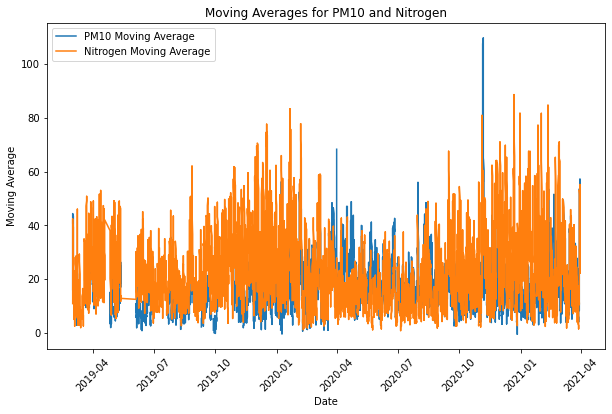

In [13]:
# Plot the moving average
plt.figure(figsize=(10, 6))
plt.plot(df1['Date'], df1['PM10 Moving Average'], label='PM10 Moving Average')
plt.plot(df1['Date'], df1['Nitrogen Moving Average'], label='Nitrogen Moving Average')
plt.xlabel('Date')
plt.ylabel('Moving Average')
plt.title('Moving Averages for PM10 and Nitrogen')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [14]:
# using moving average to fill in data
# Fill missing values with the moving averages
df1['PM10 particulate matter (Hourly measured)'].fillna(df1['PM10 Moving Average'], inplace=True)
df1['Nitrogen dioxide'].fillna(df1['Nitrogen Moving Average'], inplace=True)

# Drop the moving average columns if not needed anymore
df1.drop(['PM10 Moving Average', 'Nitrogen Moving Average'], axis=1, inplace=True)

# Print the resulting DataFrame
print(df1)

            Date                 Time  Nitrogen dioxide   Status  \
0     2019-03-01             01:00:00          10.87512  V ugm-3   
1     2019-03-01             02:00:00          15.95748  V ugm-3   
2     2019-03-01             03:00:00          11.38031  V ugm-3   
3     2019-03-01             04:00:00          14.32679  V ugm-3   
4     2019-03-01             05:00:00          12.61010  V ugm-3   
...          ...                  ...               ...      ...   
18283 2021-03-31             20:00:00          23.34129  V ugm-3   
18284 2021-03-31             21:00:00          15.88359  V ugm-3   
18285 2021-03-31             22:00:00          20.45112  V ugm-3   
18286 2021-03-31             23:00:00          12.43527  V ugm-3   
18287 2021-03-31  1900-01-01 00:00:00           7.01376  V ugm-3   

       PM10 particulate matter (Hourly measured)               Status2  
0                                           16.1   V ugm-3 (TEOM FDMS)  
1                                    

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\pandas\core\frame.py:4308: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [15]:
#Check mmissing value
missing_value = df1.isnull()
num_of_missing_value = missing_value.sum()
print(missing_value)
print(num_of_missing_value)

        Date   Time  Nitrogen dioxide  Status  \
0      False  False             False   False   
1      False  False             False   False   
2      False  False             False   False   
3      False  False             False   False   
4      False  False             False   False   
...      ...    ...               ...     ...   
18283  False  False             False   False   
18284  False  False             False   False   
18285  False  False             False   False   
18286  False  False             False   False   
18287  False  False             False   False   

       PM10 particulate matter (Hourly measured)  Status2  
0                                          False    False  
1                                          False    False  
2                                          False    False  
3                                          False    False  
4                                          False    False  
...                                          ...   

# Interpolation: 
You can use interpolation methods to estimate missing values based on the available data. Popular interpolation methods include linear interpolation, cubic interpolation, and polynomial interpolation.
Pandas provides the interpolate() method, which you can use to fill missing values with interpolated values.

In [16]:
# Interpolate missing values using linear interpolation
df1['PM10 particulate matter (Hourly measured)'] = df1['PM10 particulate matter (Hourly measured)'].interpolate(method='linear')
df1['Nitrogen dioxide'] = df1['Nitrogen dioxide'].interpolate(method='linear')


<ipython-input-16-89c60597469b>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-16-89c60597469b>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [17]:
missing_value = df1.isnull()
num_of_missing_value = missing_value.sum()
print(missing_value)
print(num_of_missing_value)

        Date   Time  Nitrogen dioxide  Status  \
0      False  False             False   False   
1      False  False             False   False   
2      False  False             False   False   
3      False  False             False   False   
4      False  False             False   False   
...      ...    ...               ...     ...   
18283  False  False             False   False   
18284  False  False             False   False   
18285  False  False             False   False   
18286  False  False             False   False   
18287  False  False             False   False   

       PM10 particulate matter (Hourly measured)  Status2  
0                                          False    False  
1                                          False    False  
2                                          False    False  
3                                          False    False  
4                                          False    False  
...                                          ...   

In [18]:
# Download the cleand dataset 
df1.to_csv('York holgate Air Quality cleaned.csv', index=False)


# Data Pre-Processing

In [19]:
df2 = pd.read_csv("York holgate Air Quality cleaned.csv")
df2

,Date,Time,Nitrogen dioxide,Status,PM10 particulate matter (Hourly measured),Status2
0,2019-03-01,01:00:00,10.87512,V ugm-3,16.1,V ugm-3 (TEOM FDMS)
1,2019-03-01,02:00:00,15.95748,V ugm-3,21.9,V ugm-3 (TEOM FDMS)
2,2019-03-01,03:00:00,11.38031,V ugm-3,24.1,V ugm-3 (TEOM FDMS)
3,2019-03-01,04:00:00,14.32679,V ugm-3,25.3,V ugm-3 (TEOM FDMS)
4,2019-03-01,05:00:00,12.61010,V ugm-3,31.9,V ugm-3 (TEOM FDMS)
...,...,...,...,...,...,...
17503,2021-03-31,20:00:00,23.34129,V ugm-3,27.9,V ugm-3 (INDIC.GRAV)
17504,2021-03-31,21:00:00,15.88359,V ugm-3,21.1,V ugm-3 (INDIC.GRAV)
17505,2021-03-31,22:00:00,20.45112,V ugm-3,18.3,V ugm-3 (INDIC.GRAV)
17506,2021-03-31,23:00:00,12.43527,V ugm-3,10.2,V ugm-3 (INDIC.GRAV)


In [20]:
# there and error in the Time column '1900-01-01 00:00:00' we will have to replace it
# Replace '1900-01-01 00:00:00' with '00:00:00'
df2['Time'] = df2['Time'].str.replace('1900-01-01 00:00:00', '00:00:00')

# Print the updated DataFrame
print(df2)

             Date      Time  Nitrogen dioxide   Status  \
0      2019-03-01  01:00:00          10.87512  V ugm-3   
1      2019-03-01  02:00:00          15.95748  V ugm-3   
2      2019-03-01  03:00:00          11.38031  V ugm-3   
3      2019-03-01  04:00:00          14.32679  V ugm-3   
4      2019-03-01  05:00:00          12.61010  V ugm-3   
...           ...       ...               ...      ...   
17503  2021-03-31  20:00:00          23.34129  V ugm-3   
17504  2021-03-31  21:00:00          15.88359  V ugm-3   
17505  2021-03-31  22:00:00          20.45112  V ugm-3   
17506  2021-03-31  23:00:00          12.43527  V ugm-3   
17507  2021-03-31  00:00:00           7.01376  V ugm-3   

       PM10 particulate matter (Hourly measured)               Status2  
0                                           16.1   V ugm-3 (TEOM FDMS)  
1                                           21.9   V ugm-3 (TEOM FDMS)  
2                                           24.1   V ugm-3 (TEOM FDMS)  
3          

In [21]:
#Combine 'Date' and 'Time' columns into a single datetime column
df2['DateTime'] = pd.to_datetime(df2['Date'].astype(str) + ' ' + df2['Time'])
df2 = df2.drop(['Date', 'Time'], axis=1)
df2

,Nitrogen dioxide,Status,PM10 particulate matter (Hourly measured),Status2,DateTime
0,10.87512,V ugm-3,16.1,V ugm-3 (TEOM FDMS),2019-03-01 01:00:00
1,15.95748,V ugm-3,21.9,V ugm-3 (TEOM FDMS),2019-03-01 02:00:00
2,11.38031,V ugm-3,24.1,V ugm-3 (TEOM FDMS),2019-03-01 03:00:00
3,14.32679,V ugm-3,25.3,V ugm-3 (TEOM FDMS),2019-03-01 04:00:00
4,12.61010,V ugm-3,31.9,V ugm-3 (TEOM FDMS),2019-03-01 05:00:00
...,...,...,...,...,...
17503,23.34129,V ugm-3,27.9,V ugm-3 (INDIC.GRAV),2021-03-31 20:00:00
17504,15.88359,V ugm-3,21.1,V ugm-3 (INDIC.GRAV),2021-03-31 21:00:00
17505,20.45112,V ugm-3,18.3,V ugm-3 (INDIC.GRAV),2021-03-31 22:00:00
17506,12.43527,V ugm-3,10.2,V ugm-3 (INDIC.GRAV),2021-03-31 23:00:00


In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17508 entries, 0 to 17507
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Nitrogen dioxide                           17508 non-null  float64       
 1   Status                                     17467 non-null  object        
 2   PM10 particulate matter (Hourly measured)  17508 non-null  float64       
 3   Status2                                    17386 non-null  object        
 4   DateTime                                   17508 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 684.0+ KB


In [23]:
#Convert object ' Status' 'Status2' to numerical values using one-hot encoding
df2 = pd.get_dummies(df2, columns=['Status', 'Status2'])


In [24]:
df2.head(8)

,Nitrogen dioxide,PM10 particulate matter (Hourly measured),DateTime,Status_V ugm-3,Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM)
0,10.87512,16.1,2019-03-01 01:00:00,1,0,1,0
1,15.95748,21.9,2019-03-01 02:00:00,1,0,1,0
2,11.38031,24.1,2019-03-01 03:00:00,1,0,1,0
3,14.32679,25.3,2019-03-01 04:00:00,1,0,1,0
4,12.61010,31.9,2019-03-01 05:00:00,1,0,1,0
5,15.71974,30.0,2019-03-01 06:00:00,1,0,1,0
6,37.31443,31.3,2019-03-01 07:00:00,1,0,1,0
7,46.28878,35.5,2019-03-01 08:00:00,1,0,1,0


In [25]:
# rearrnage columns
# Define the desired column order
desired_columns = ['DateTime', 'Nitrogen dioxide', 'Status_V ugm-3',
                   'PM10 particulate matter (Hourly measured)',
                   'Status2_V ugm-3 (INDIC.GRAV)', 'Status2_V ugm-3 (TEOM FDMS)',
                   'Status2_V ugm-3 (VCM)']

# Rearrange the columns in the DataFrame
df2 = df2.reindex(columns=desired_columns)

# Print the updated DataFrame
print(df2)

                 DateTime  Nitrogen dioxide  Status_V ugm-3  \
0     2019-03-01 01:00:00          10.87512               1   
1     2019-03-01 02:00:00          15.95748               1   
2     2019-03-01 03:00:00          11.38031               1   
3     2019-03-01 04:00:00          14.32679               1   
4     2019-03-01 05:00:00          12.61010               1   
...                   ...               ...             ...   
17503 2021-03-31 20:00:00          23.34129               1   
17504 2021-03-31 21:00:00          15.88359               1   
17505 2021-03-31 22:00:00          20.45112               1   
17506 2021-03-31 23:00:00          12.43527               1   
17507 2021-03-31 00:00:00           7.01376               1   

       PM10 particulate matter (Hourly measured)  \
0                                           16.1   
1                                           21.9   
2                                           24.1   
3                                  

In [26]:
# Convert 'DateTime' column to datetime with utc=True
df2['DateTime'] = pd.to_datetime(df2['DateTime'], utc=True)

# Print the updated DataFrame
print(df2)

                       DateTime  Nitrogen dioxide  Status_V ugm-3  \
0     2019-03-01 01:00:00+00:00          10.87512               1   
1     2019-03-01 02:00:00+00:00          15.95748               1   
2     2019-03-01 03:00:00+00:00          11.38031               1   
3     2019-03-01 04:00:00+00:00          14.32679               1   
4     2019-03-01 05:00:00+00:00          12.61010               1   
...                         ...               ...             ...   
17503 2021-03-31 20:00:00+00:00          23.34129               1   
17504 2021-03-31 21:00:00+00:00          15.88359               1   
17505 2021-03-31 22:00:00+00:00          20.45112               1   
17506 2021-03-31 23:00:00+00:00          12.43527               1   
17507 2021-03-31 00:00:00+00:00           7.01376               1   

       PM10 particulate matter (Hourly measured)  \
0                                           16.1   
1                                           21.9   
2              

In [27]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17508 entries, 0 to 17507
Data columns (total 7 columns):
 #   Column                                     Non-Null Count  Dtype              
---  ------                                     --------------  -----              
 0   DateTime                                   17508 non-null  datetime64[ns, UTC]
 1   Nitrogen dioxide                           17508 non-null  float64            
 2   Status_V ugm-3                             17508 non-null  uint8              
 3   PM10 particulate matter (Hourly measured)  17508 non-null  float64            
 4   Status2_V ugm-3 (INDIC.GRAV)               17508 non-null  uint8              
 5   Status2_V ugm-3 (TEOM FDMS)                17508 non-null  uint8              
 6   Status2_V ugm-3 (VCM)                      17508 non-null  uint8              
dtypes: datetime64[ns, UTC](1), float64(2), uint8(4)
memory usage: 478.9 KB


In [28]:
df2.head(5)

,DateTime,Nitrogen dioxide,Status_V ugm-3,PM10 particulate matter (Hourly measured),Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM)
0,2019-03-01 01:00:00+00:00,10.87512,1,16.1,0,1,0
1,2019-03-01 02:00:00+00:00,15.95748,1,21.9,0,1,0
2,2019-03-01 03:00:00+00:00,11.38031,1,24.1,0,1,0
3,2019-03-01 04:00:00+00:00,14.32679,1,25.3,0,1,0
4,2019-03-01 05:00:00+00:00,12.61010,1,31.9,0,1,0


Summary statistics for 'Nitrogen dioxide':
count    17508.000000
mean        22.682000
std         15.555865
min          0.419010
25%         10.978630
50%         18.936120
75%         30.822283
max        131.200300
Name: Nitrogen dioxide, dtype: float64
Summary statistics for 'PM10 particulate matter':
count    17508.000000
mean        16.038767
std         10.135609
min         -4.500000
25%          9.200000
50%         13.800000
75%         20.644820
max        173.500000
Name: PM10 particulate matter (Hourly measured), dtype: float64


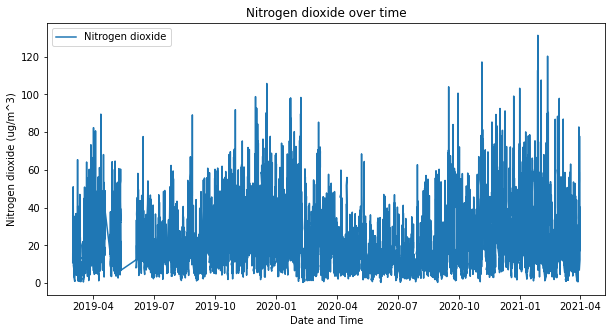

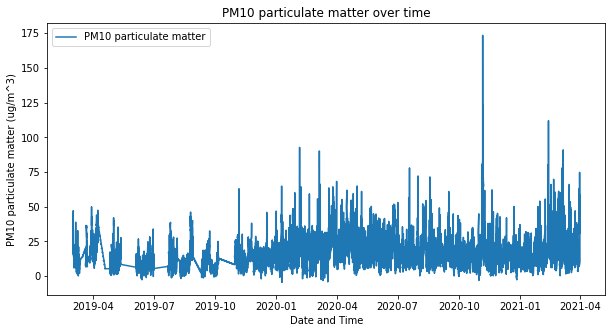

In [29]:
#  Data selection and basic analysis for 'Nitrogen dioxide' and 'PM10 particulate matter'
nitrogen_column = df2['Nitrogen dioxide']
pm10_column = df2['PM10 particulate matter (Hourly measured)']

# Calculate summary statistics for 'Nitrogen dioxide'
print("Summary statistics for 'Nitrogen dioxide':")
print(nitrogen_column.describe())

# Calculate summary statistics for 'PM10 particulate matter'
print("Summary statistics for 'PM10 particulate matter':")
print(pm10_column.describe())

#Data visualization (Optional)

# Plotting 'Nitrogen dioxide' over time
plt.figure(figsize=(10, 5))
plt.plot(df2['DateTime'], nitrogen_column, label='Nitrogen dioxide')
plt.xlabel('Date and Time')
plt.ylabel('Nitrogen dioxide (ug/m^3)')
plt.title('Nitrogen dioxide over time')
plt.legend()
plt.show()

# Plotting 'PM10 particulate matter' over time
plt.figure(figsize=(10, 5))
plt.plot(df2['DateTime'], pm10_column, label='PM10 particulate matter')
plt.xlabel('Date and Time')
plt.ylabel('PM10 particulate matter (ug/m^3)')
plt.title('PM10 particulate matter over time')
plt.legend()
plt.show()



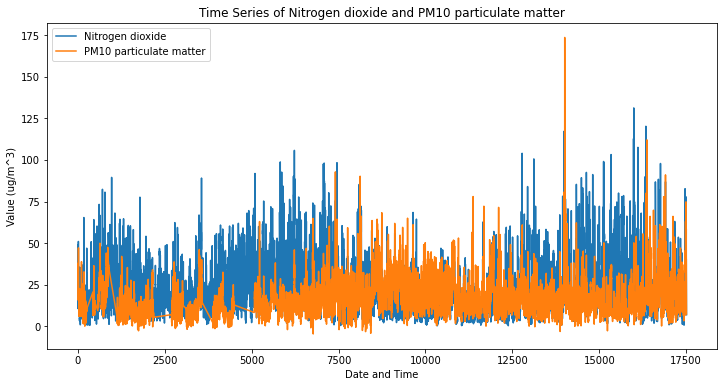

Outliers in 'Nitrogen dioxide':
                       DateTime  Nitrogen dioxide  Status_V ugm-3  \
615   2019-03-28 08:00:00+00:00          73.29520               1   
709   2019-04-01 06:00:00+00:00          75.09992               1   
710   2019-04-01 07:00:00+00:00          82.35507               1   
782   2019-04-04 07:00:00+00:00          80.64806               1   
973   2019-04-12 06:00:00+00:00          71.18963               1   
...                         ...               ...             ...   
16903 2021-03-06 20:00:00+00:00          86.88104               1   
17466 2021-03-30 07:00:00+00:00          82.70877               1   
17467 2021-03-30 08:00:00+00:00          81.28865               1   
17480 2021-03-30 21:00:00+00:00          76.11111               1   
17490 2021-03-31 07:00:00+00:00          77.86958               1   

       PM10 particulate matter (Hourly measured)  \
615                                    24.800000   
709                                

In [30]:
# Plotting the time series data to visually inspect for outliers
plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['Nitrogen dioxide'], label='Nitrogen dioxide')
plt.plot(df2.index, df2['PM10 particulate matter (Hourly measured)'], label='PM10 particulate matter')
plt.xlabel('Date and Time')
plt.ylabel('Value (ug/m^3)')
plt.title('Time Series of Nitrogen dioxide and PM10 particulate matter')
plt.legend()
plt.show()

# Outlier Detection using Z-Score
from scipy.stats import zscore

# Compute Z-scores for 'Nitrogen dioxide' and 'PM10 particulate matter'
z_scores_nitrogen = zscore(df2['Nitrogen dioxide'])
z_scores_pm10 = zscore(df2['PM10 particulate matter (Hourly measured)'])

# Define a threshold for outlier detection (e.g., 3 or 2.5)
threshold = 3

# Identify outliers for 'Nitrogen dioxide'
outliers_nitrogen = df2[abs(z_scores_nitrogen) > threshold]

# Identify outliers for 'PM10 particulate matter'
outliers_pm10 = df2[abs(z_scores_pm10) > threshold]

# Display the outliers
print("Outliers in 'Nitrogen dioxide':")
print(outliers_nitrogen)
print("\nOutliers in 'PM10 particulate matter':")
print(outliers_pm10)


In [31]:

# Split the data into training and validation sets
train_size = int(0.8 * len(df2))
train_data = df2.iloc[:train_size]
validation_data = df2.iloc[train_size:]

# Define a range of window sizes to evaluate
window_sizes = [3, 5, 7, 10, 15, 20, 30]

#Initialize variables to store the best window size and MSE
best_window_size_nitrogen = None
best_mse_nitrogen = float('inf')

best_window_size_pm10 = None
best_mse_pm10 = float('inf')

# Perform cross-validation and find the best window size based on MSE for 'Nitrogen dioxide'
for window_size in window_sizes:
    # Smoothing 'Nitrogen dioxide' using moving average with the current window size
    train_data['Nitrogen_dioxide_smoothed'] = train_data['Nitrogen dioxide'].rolling(window=window_size, min_periods=1).mean()
    validation_data['Nitrogen_dioxide_smoothed'] = validation_data['Nitrogen dioxide'].rolling(window=window_size, min_periods=1).mean()
    
    # Calculate MSE on the validation set
    mse = ((validation_data['Nitrogen dioxide'] - validation_data['Nitrogen_dioxide_smoothed']) ** 2).mean()
    
    # Update the best window size if the current MSE is lower than the previous best
    if mse < best_mse_nitrogen:
        best_mse_nitrogen = mse
        best_window_size_nitrogen = window_size

print("Best Window Size for 'Nitrogen dioxide' is:", best_window_size_nitrogen)

#Perform cross-validation and find the best window size based on MSE for 'PM10 particulate matter'
for window_size in window_sizes:
    # Smoothing 'PM10 particulate matter' using moving average with the current window size
    train_data['PM10_pm_smoothed'] = train_data['PM10 particulate matter (Hourly measured)'].rolling(window=window_size, min_periods=1).mean()
    validation_data['PM10_pm_smoothed'] = validation_data['PM10 particulate matter (Hourly measured)'].rolling(window=window_size, min_periods=1).mean()
    
    # Calculate MSE on the validation set
    mse = ((validation_data['PM10 particulate matter (Hourly measured)'] - validation_data['PM10_pm_smoothed']) ** 2).mean()
    
    # Update the best window size if the current MSE is lower than the previous best
    if mse < best_mse_pm10:
        best_mse_pm10 = mse
        best_window_size_pm10 = window_size

print("Best Window Size for 'PM10 particulate matter' is:", best_window_size_pm10)


Best Window Size for 'Nitrogen dioxide' is: 3
Best Window Size for 'PM10 particulate matter' is: 3


<ipython-input-31-dec127d062f4>:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-31-dec127d062f4>:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-31-dec127d062f4>:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-31-dec1

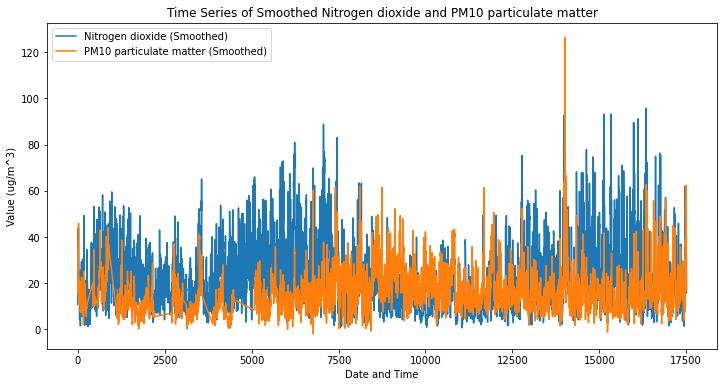

In [32]:
# Data Smoothing using Moving Average
# Let's use a simple moving average to smooth the time series data

window_size = 5  # Adjust the window size based on your data and smoothing requirements

# Smoothing 'Nitrogen dioxide' using moving average
df2['Nitrogen_dioxide_smoothed'] = df2['Nitrogen dioxide'].rolling(window=window_size, min_periods=1).mean()

# Smoothing 'PM10 particulate matter' using moving average
df2['PM10_pm_smoothed'] = df2['PM10 particulate matter (Hourly measured)'].rolling(window=window_size, min_periods=1).mean()

# Plotting the smoothed data
plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['Nitrogen_dioxide_smoothed'], label='Nitrogen dioxide (Smoothed)')
plt.plot(df2.index, df2['PM10_pm_smoothed'], label='PM10 particulate matter (Smoothed)')
plt.xlabel('Date and Time')
plt.ylabel('Value (ug/m^3)')
plt.title('Time Series of Smoothed Nitrogen dioxide and PM10 particulate matter')
plt.legend()
plt.show()


In [33]:
df2

,DateTime,Nitrogen dioxide,Status_V ugm-3,PM10 particulate matter (Hourly measured),Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM),Nitrogen_dioxide_smoothed,PM10_pm_smoothed
0,2019-03-01 01:00:00+00:00,10.87512,1,16.1,0,1,0,10.875120,16.10
1,2019-03-01 02:00:00+00:00,15.95748,1,21.9,0,1,0,13.416300,19.00
2,2019-03-01 03:00:00+00:00,11.38031,1,24.1,0,1,0,12.737637,20.70
3,2019-03-01 04:00:00+00:00,14.32679,1,25.3,0,1,0,13.134925,21.85
4,2019-03-01 05:00:00+00:00,12.61010,1,31.9,0,1,0,13.029960,23.86
...,...,...,...,...,...,...,...,...,...
17503,2021-03-31 20:00:00+00:00,23.34129,1,27.9,1,0,0,32.110080,43.88
17504,2021-03-31 21:00:00+00:00,15.88359,1,21.1,1,0,0,30.521020,39.58
17505,2021-03-31 22:00:00+00:00,20.45112,1,18.3,1,0,0,27.228874,33.78
17506,2021-03-31 23:00:00+00:00,12.43527,1,10.2,1,0,0,21.640884,24.12


In [34]:
# Download the pre-processed dataset 
df2.to_csv('York holgate Air Quality pre-processed1.csv', index=False)


# Discriptive Analysis

In [35]:
df3 = pd.read_csv("York holgate Air Quality pre-processed1.csv")
df3.head(7)

,DateTime,Nitrogen dioxide,Status_V ugm-3,PM10 particulate matter (Hourly measured),Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM),Nitrogen_dioxide_smoothed,PM10_pm_smoothed
0,2019-03-01 01:00:00+00:00,10.87512,1,16.1,0,1,0,10.875120,16.10
1,2019-03-01 02:00:00+00:00,15.95748,1,21.9,0,1,0,13.416300,19.00
2,2019-03-01 03:00:00+00:00,11.38031,1,24.1,0,1,0,12.737637,20.70
3,2019-03-01 04:00:00+00:00,14.32679,1,25.3,0,1,0,13.134925,21.85
4,2019-03-01 05:00:00+00:00,12.61010,1,31.9,0,1,0,13.029960,23.86
5,2019-03-01 06:00:00+00:00,15.71974,1,30.0,0,1,0,13.998884,26.64
6,2019-03-01 07:00:00+00:00,37.31443,1,31.3,0,1,0,18.270274,28.52


In [36]:
# Make the Nitrogen_dioxide_smoothed and PM10_pm_smoothed the new Nitrogen dioxide and PM10 particulate matter (Hourly measured)
# and Drop the original Nitrogen dioxide and PM10 particulate matter (Hourly measured)

# Drop the original columns
df3.drop(columns=['Nitrogen dioxide', 'PM10 particulate matter (Hourly measured)'], inplace=True)

# Rename the columns
df3.rename(columns={'Nitrogen_dioxide_smoothed': 'Nitrogen dioxide', 'PM10_pm_smoothed': 'PM10 particulate matter (Hourly measured)'}, inplace=True)

# Print the updated DataFrame
print(df3)


                        DateTime  Status_V ugm-3  \
0      2019-03-01 01:00:00+00:00               1   
1      2019-03-01 02:00:00+00:00               1   
2      2019-03-01 03:00:00+00:00               1   
3      2019-03-01 04:00:00+00:00               1   
4      2019-03-01 05:00:00+00:00               1   
...                          ...             ...   
17503  2021-03-31 20:00:00+00:00               1   
17504  2021-03-31 21:00:00+00:00               1   
17505  2021-03-31 22:00:00+00:00               1   
17506  2021-03-31 23:00:00+00:00               1   
17507  2021-03-31 00:00:00+00:00               1   

       Status2_V ugm-3 (INDIC.GRAV)  Status2_V ugm-3 (TEOM FDMS)  \
0                                 0                            1   
1                                 0                            1   
2                                 0                            1   
3                                 0                            1   
4                                 0

In [37]:
df3.head(7)

,DateTime,Status_V ugm-3,Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM),Nitrogen dioxide,PM10 particulate matter (Hourly measured)
0,2019-03-01 01:00:00+00:00,1,0,1,0,10.875120,16.10
1,2019-03-01 02:00:00+00:00,1,0,1,0,13.416300,19.00
2,2019-03-01 03:00:00+00:00,1,0,1,0,12.737637,20.70
3,2019-03-01 04:00:00+00:00,1,0,1,0,13.134925,21.85
4,2019-03-01 05:00:00+00:00,1,0,1,0,13.029960,23.86
5,2019-03-01 06:00:00+00:00,1,0,1,0,13.998884,26.64
6,2019-03-01 07:00:00+00:00,1,0,1,0,18.270274,28.52


In [38]:
# re arrange the columns
# Reorder the columns as desired
new_column_order = [
    'DateTime',
    'Nitrogen dioxide',
    'PM10 particulate matter (Hourly measured)',
    'Status_V ugm-3',
    'Status2_V ugm-3 (INDIC.GRAV)',
    'Status2_V ugm-3 (TEOM FDMS)',
    'Status2_V ugm-3 (VCM)'
]

df3 = df3.reindex(columns=new_column_order)

# Step 3: Print the updated DataFrame
print(df3)


                        DateTime  Nitrogen dioxide  \
0      2019-03-01 01:00:00+00:00         10.875120   
1      2019-03-01 02:00:00+00:00         13.416300   
2      2019-03-01 03:00:00+00:00         12.737637   
3      2019-03-01 04:00:00+00:00         13.134925   
4      2019-03-01 05:00:00+00:00         13.029960   
...                          ...               ...   
17503  2021-03-31 20:00:00+00:00         32.110080   
17504  2021-03-31 21:00:00+00:00         30.521020   
17505  2021-03-31 22:00:00+00:00         27.228874   
17506  2021-03-31 23:00:00+00:00         21.640884   
17507  2021-03-31 00:00:00+00:00         15.825006   

       PM10 particulate matter (Hourly measured)  Status_V ugm-3  \
0                                          16.10               1   
1                                          19.00               1   
2                                          20.70               1   
3                                          21.85               1   
4          

In [39]:
df3.shape

(17508, 7)

In [40]:
df3.columns

Index(['DateTime', 'Nitrogen dioxide',
       'PM10 particulate matter (Hourly measured)', 'Status_V ugm-3',
       'Status2_V ugm-3 (INDIC.GRAV)', 'Status2_V ugm-3 (TEOM FDMS)',
       'Status2_V ugm-3 (VCM)'],
      dtype='object')

In [41]:
 df3.describe()

,Nitrogen dioxide,PM10 particulate matter (Hourly measured),Status_V ugm-3,Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM)
count,17508.000000,17508.000000,17508.000000,17508.000000,17508.000000,17508.000000
mean,22.682002,16.039529,0.997658,0.604295,0.282842,0.105894
std,13.926053,9.231229,0.048337,0.489016,0.450393,0.307711
min,0.746080,-1.940000,0.000000,0.000000,0.000000,0.000000
25%,12.010210,9.620000,1.000000,0.000000,0.000000,0.000000
50%,19.793510,14.120912,1.000000,1.000000,0.000000,0.000000
75%,30.410760,20.500000,1.000000,1.000000,1.000000,0.000000
max,95.714012,126.340000,1.000000,1.000000,1.000000,1.000000


In [42]:
df3.isnull().sum()

DateTime                                     0
Nitrogen dioxide                             0
PM10 particulate matter (Hourly measured)    0
Status_V ugm-3                               0
Status2_V ugm-3 (INDIC.GRAV)                 0
Status2_V ugm-3 (TEOM FDMS)                  0
Status2_V ugm-3 (VCM)                        0
dtype: int64

In [43]:
df3.dtypes

DateTime                                      object
Nitrogen dioxide                             float64
PM10 particulate matter (Hourly measured)    float64
Status_V ugm-3                                 int64
Status2_V ugm-3 (INDIC.GRAV)                   int64
Status2_V ugm-3 (TEOM FDMS)                    int64
Status2_V ugm-3 (VCM)                          int64
dtype: object

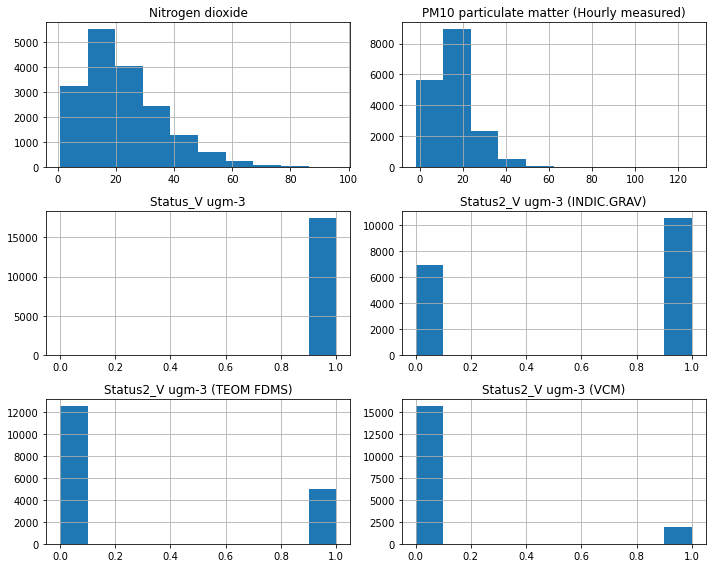

In [44]:
# Plot to show the frequency
df3.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [45]:
# Convert 'DateTime' column to datetime 
df3['DateTime'] = pd.to_datetime(df3['DateTime'])

# Print the updaated DataFrame
print(df3.dtypes)

DateTime                                     datetime64[ns, UTC]
Nitrogen dioxide                                         float64
PM10 particulate matter (Hourly measured)                float64
Status_V ugm-3                                             int64
Status2_V ugm-3 (INDIC.GRAV)                               int64
Status2_V ugm-3 (TEOM FDMS)                                int64
Status2_V ugm-3 (VCM)                                      int64
dtype: object


In [46]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17508 entries, 0 to 17507
Data columns (total 7 columns):
 #   Column                                     Non-Null Count  Dtype              
---  ------                                     --------------  -----              
 0   DateTime                                   17508 non-null  datetime64[ns, UTC]
 1   Nitrogen dioxide                           17508 non-null  float64            
 2   PM10 particulate matter (Hourly measured)  17508 non-null  float64            
 3   Status_V ugm-3                             17508 non-null  int64              
 4   Status2_V ugm-3 (INDIC.GRAV)               17508 non-null  int64              
 5   Status2_V ugm-3 (TEOM FDMS)                17508 non-null  int64              
 6   Status2_V ugm-3 (VCM)                      17508 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(2), int64(4)
memory usage: 957.6 KB


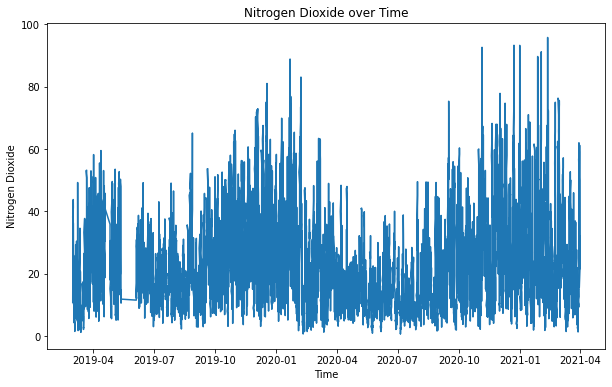

In [47]:
# Plot the Nitrogen dioxide over time

plt.figure(figsize=(10, 6))
plt.plot(df3['DateTime'], df3['Nitrogen dioxide'])
plt.title('Nitrogen Dioxide over Time')
plt.xlabel('Time')
plt.ylabel('Nitrogen Dioxide')
plt.show()


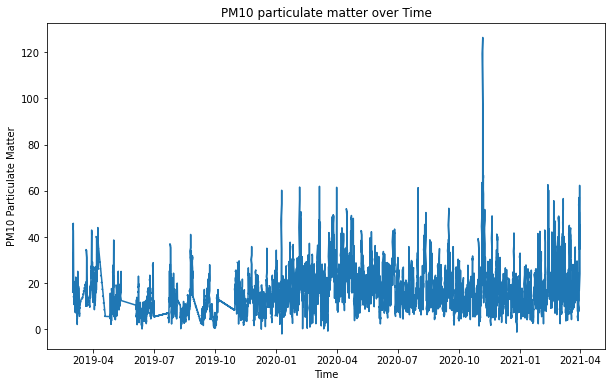

In [48]:
# Plot the PM10 over time
plt.figure(figsize=(10, 6))
plt.plot(df3['DateTime'], df3['PM10 particulate matter (Hourly measured)'])
plt.title('PM10 particulate matter over Time')
plt.xlabel('Time')
plt.ylabel('PM10 Particulate Matter')
plt.show()


# Nitrogen

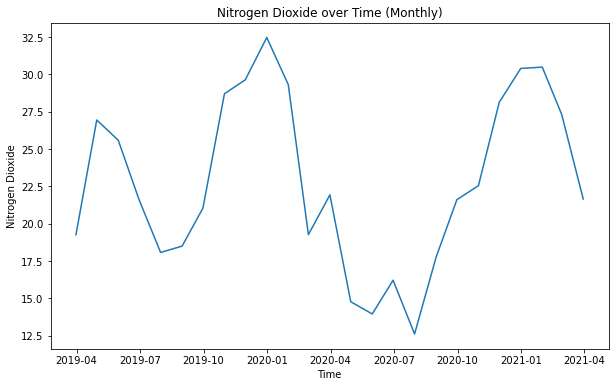

In [49]:
# Resample the data to monthly frequency
df_monthly = df3.resample('M', on='DateTime').mean()

# Plot the Nitrogen dioxide over time on a monthly basis
plt.figure(figsize=(10, 6))
plt.plot(df_monthly.index, df_monthly['Nitrogen dioxide'])
plt.title('Nitrogen Dioxide over Time (Monthly)')
plt.xlabel('Time')
plt.ylabel('Nitrogen Dioxide')
plt.show()


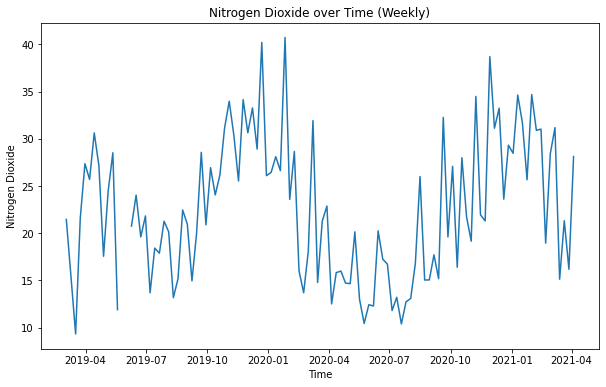

In [50]:
# Resample the data to weekly frequency
df_weekly = df3.resample('W', on='DateTime').mean()

# Plot the Nitrogen dioxide over time on a weekly basis
plt.figure(figsize=(10, 6))
plt.plot(df_weekly.index, df_weekly['Nitrogen dioxide'])
plt.title('Nitrogen Dioxide over Time (Weekly)')
plt.xlabel('Time')
plt.ylabel('Nitrogen Dioxide')
plt.show()


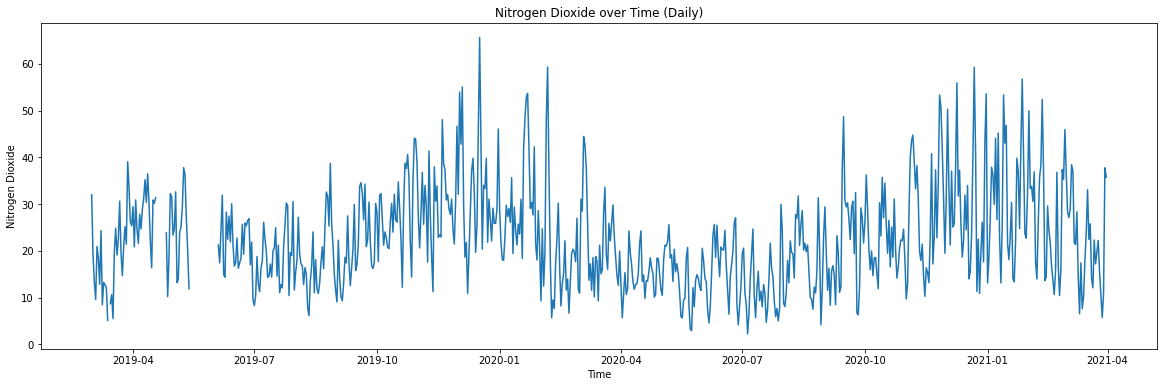

In [51]:
# Resample the data to daily frequency
df_daily = df3.resample('D', on='DateTime').mean()

# Plot the Nitrogen dioxide over time on a daily basis
plt.figure(figsize=(20, 6))
plt.plot(df_daily.index, df_daily['Nitrogen dioxide'])
plt.title('Nitrogen Dioxide over Time (Daily)')
plt.xlabel('Time')
plt.ylabel('Nitrogen Dioxide')
plt.show()


# PM10

In [52]:
# Plot the montly, Weekly amd Daily frequency
def plot_resampled_data(data, column_name):
    # Convert 'DateTime' column to datetime data type
    data['DateTime'] = pd.to_datetime(data['DateTime'])
    
    # Set 'DateTime' as the index
    data.set_index('DateTime', inplace=True)

    # Resample the data to monthly frequency
    data_monthly = data[column_name].resample('M').mean()

    # Plot the data over time on a monthly basis
    plt.figure(figsize=(10, 6))
    plt.plot(data_monthly.index, data_monthly)
    plt.title(column_name + ' over Time (Monthly)')
    plt.xlabel('Time')
    plt.ylabel(column_name)
    plt.show()

    # Resample the data to weekly frequency
    data_weekly = data[column_name].resample('W').mean()

    # Plot the data over time on a weekly basis
    plt.figure(figsize=(10, 6))
    plt.plot(data_weekly.index, data_weekly)
    plt.title(column_name + ' over Time (Weekly)')
    plt.xlabel('Time')
    plt.ylabel(column_name)
    plt.show()

    # Resample the data to daily frequency
    data_daily = data[column_name].resample('D').mean()

    # Plot the data over time on a daily basis
    plt.figure(figsize=(20, 6))
    plt.plot(data_daily.index, data_daily)
    plt.title(column_name + ' over Time (Daily)')
    plt.xlabel('Time')
    plt.ylabel(column_name)
    plt.show()


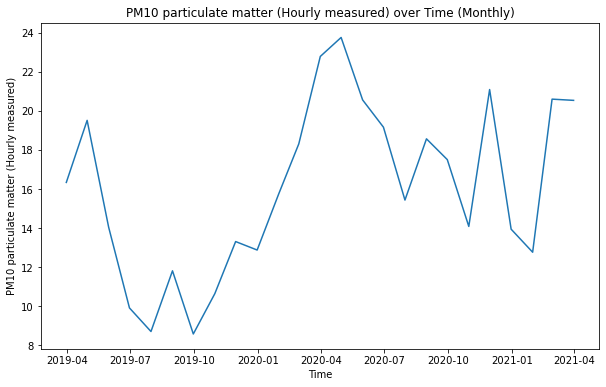

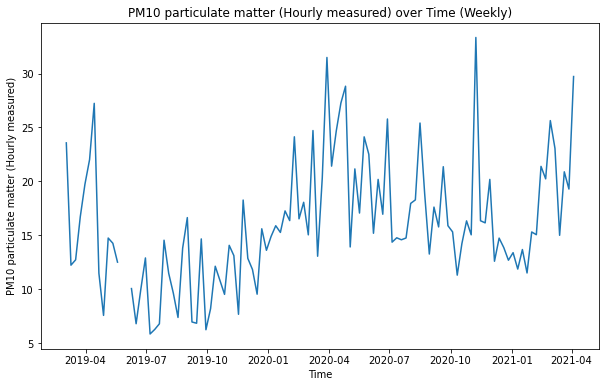

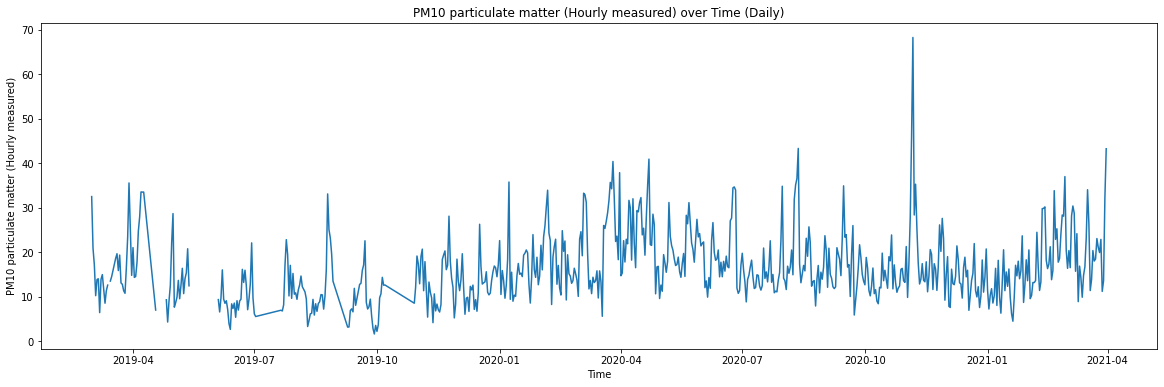

In [53]:
plot_resampled_data(df3, 'PM10 particulate matter (Hourly measured)')


In [54]:
df3.dtypes

Nitrogen dioxide                             float64
PM10 particulate matter (Hourly measured)    float64
Status_V ugm-3                                 int64
Status2_V ugm-3 (INDIC.GRAV)                   int64
Status2_V ugm-3 (TEOM FDMS)                    int64
Status2_V ugm-3 (VCM)                          int64
dtype: object

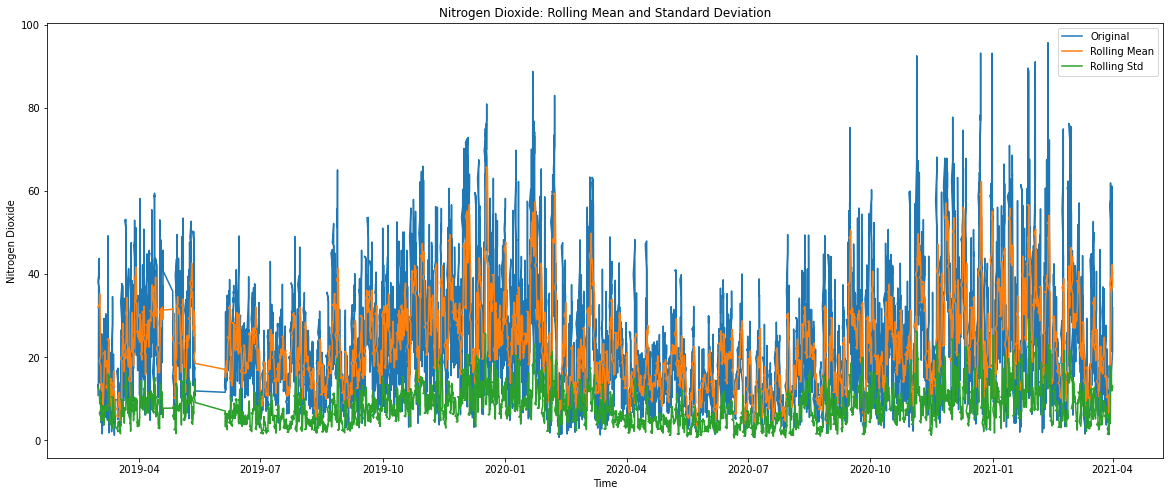

In [55]:
# Perform rolling mean and standard deviation calculations
window = 24  # Adjust the window size according to your dataset
rolling_mean = df3['Nitrogen dioxide'].rolling(window=window).mean()
rolling_std = df3['Nitrogen dioxide'].rolling(window=window).std()

# Plot the rolling statistics
plt.figure(figsize=(20, 8))
plt.plot(df3.index, df3['Nitrogen dioxide'], label='Original')
plt.plot(rolling_mean.index, rolling_mean, label='Rolling Mean')
plt.plot(rolling_std.index, rolling_std, label='Rolling Std')
plt.title('Nitrogen Dioxide: Rolling Mean and Standard Deviation')
plt.xlabel('Time')
plt.ylabel('Nitrogen Dioxide')
plt.legend()
plt.show()


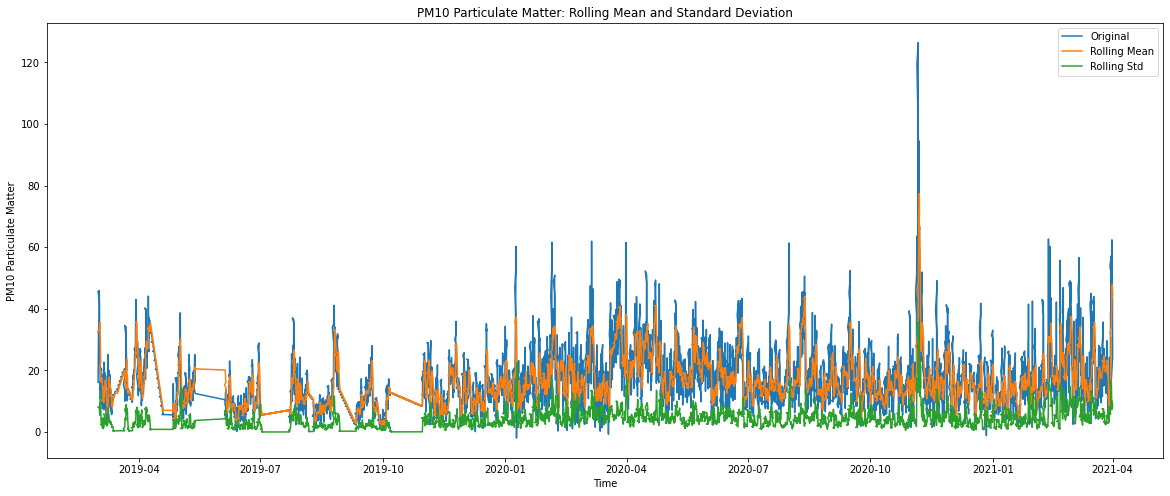

In [56]:
# Perform rolling mean and standard deviation calculations for PM10
window = 24  # Adjust the window size according to your dataset
rolling_mean_pm10 = df3['PM10 particulate matter (Hourly measured)'].rolling(window=window).mean()
rolling_std_pm10 = df3['PM10 particulate matter (Hourly measured)'].rolling(window=window).std()

# Plot the rolling statistics for PM10
plt.figure(figsize=(20, 8))
plt.plot(df3.index, df3['PM10 particulate matter (Hourly measured)'], label='Original')
plt.plot(rolling_mean_pm10.index, rolling_mean_pm10, label='Rolling Mean')
plt.plot(rolling_std_pm10.index, rolling_std_pm10, label='Rolling Std')
plt.title('PM10 Particulate Matter: Rolling Mean and Standard Deviation')
plt.xlabel('Time')
plt.ylabel('PM10 Particulate Matter')
plt.legend()
plt.show()


# Correlation

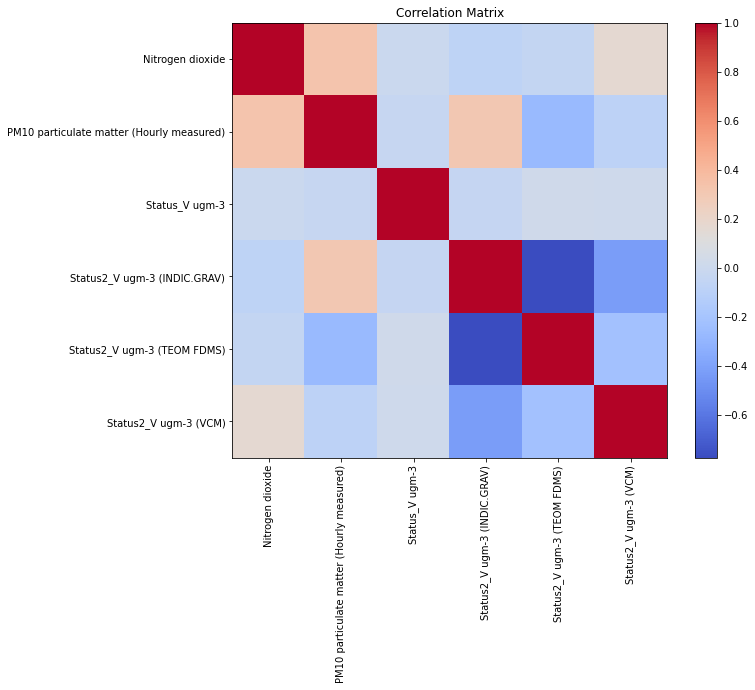

In [57]:
# Calculate the correlation matrix
correlation_matrix = df3.corr()

# Create a heatmap to visualize the correlations
plt.figure(figsize=(10, 8))
plt.title('Correlation Matrix')
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()


In [58]:
# Calculate the correlation between 'Nitrogen dioxide' and 'PM10 particulate matter (Hourly measured)'
correlation = df3['Nitrogen dioxide'].corr(df3['PM10 particulate matter (Hourly measured)'])

# Print the correlation
print("Correlation between Nitrogen dioxide and PM10 particulate matter:", correlation)


Correlation between Nitrogen dioxide and PM10 particulate matter: 0.3298667243808779


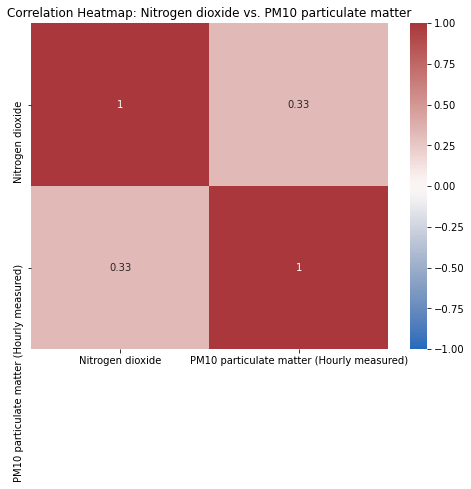

In [59]:
# Calculate the correlation matrix
correlation_matrix = df3[['Nitrogen dioxide', 'PM10 particulate matter (Hourly measured)']].corr()

# Create a heatmap to visualize the correlations with a blue gradient color
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Nitrogen dioxide vs. PM10 particulate matter')
plt.show()


# Time Series

# Test statistic for stationarity
## Hypothesis
* Null hypothesis: Not Stationaty
* Alternate hypothesis: Stationary

* **Critical Regrion : Regect the null hypothesis at 0.05 level of significances if p-value less than level of significance** 

In [60]:
missing_value = df3.isnull()
num_of_missing_value = missing_value.sum()
print(missing_value)
print(num_of_missing_value)

                           Nitrogen dioxide  \
DateTime                                      
2019-03-01 01:00:00+00:00             False   
2019-03-01 02:00:00+00:00             False   
2019-03-01 03:00:00+00:00             False   
2019-03-01 04:00:00+00:00             False   
2019-03-01 05:00:00+00:00             False   
...                                     ...   
2021-03-31 20:00:00+00:00             False   
2021-03-31 21:00:00+00:00             False   
2021-03-31 22:00:00+00:00             False   
2021-03-31 23:00:00+00:00             False   
2021-03-31 00:00:00+00:00             False   

                           PM10 particulate matter (Hourly measured)  \
DateTime                                                               
2019-03-01 01:00:00+00:00                                      False   
2019-03-01 02:00:00+00:00                                      False   
2019-03-01 03:00:00+00:00                                      False   
2019-03-01 04:00:00+00:00   

In [61]:
df3

,Nitrogen dioxide,PM10 particulate matter (Hourly measured),Status_V ugm-3,Status2_V ugm-3 (INDIC.GRAV),Status2_V ugm-3 (TEOM FDMS),Status2_V ugm-3 (VCM)
DateTime,,,,,,
2019-03-01 01:00:00+00:00,10.875120,16.10,1,0,1,0
2019-03-01 02:00:00+00:00,13.416300,19.00,1,0,1,0
2019-03-01 03:00:00+00:00,12.737637,20.70,1,0,1,0
2019-03-01 04:00:00+00:00,13.134925,21.85,1,0,1,0
2019-03-01 05:00:00+00:00,13.029960,23.86,1,0,1,0
...,...,...,...,...,...,...
2021-03-31 20:00:00+00:00,32.110080,43.88,1,1,0,0
2021-03-31 21:00:00+00:00,30.521020,39.58,1,1,0,0
2021-03-31 22:00:00+00:00,27.228874,33.78,1,1,0,0


In [62]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# Function to perform the Augmented Dickey-Fuller (ADF) test
def adf_test(series):
    """
    Perform the Augmented Dickey-Fuller (ADF) test on a time series.

    Parameters:
        series (pd.Series): The time series data.

    Returns:
        dict: A dictionary containing the ADF test results.
    """
    result = adfuller(series.dropna())  # Drop any rows with missing values before the test
    adf_test_results = {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Lags Used': result[2],
        'Number of Observations Used': result[3],
        'Critical Values': result[4]
    }
    return adf_test_results

# Function to perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test
def kpss_test(series):
    """
    Perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test on a time series.

    Parameters:
        series (pd.Series): The time series data.

    Returns:
        dict: A dictionary containing the KPSS test results.
    """
    result = kpss(series.dropna())  # Drop any rows with missing values before the test
    kpss_test_results = {
        'KPSS Statistic': result[0],
        'p-value': result[1],
        'Lags Used': result[1],
        'Critical Values': result[3]
    }
    return kpss_test_results


# Perform ADF and KPSS tests for Nitrogen dioxide
nitrogen_dioxide_series = df3['Nitrogen dioxide']
nitrogen_dioxide_adf_results = adf_test(nitrogen_dioxide_series)
nitrogen_dioxide_kpss_results = kpss_test(nitrogen_dioxide_series)
print("ADF Test Results for Nitrogen Dioxide:")
print(nitrogen_dioxide_adf_results)
print("\nKPSS Test Results for Nitrogen Dioxide:")
print(nitrogen_dioxide_kpss_results)

# Perform ADF and KPSS tests for PM10 particulate matter (Hourly measured)
pm10_series = df3['PM10 particulate matter (Hourly measured)']
pm10_adf_results = adf_test(pm10_series)
pm10_kpss_results = kpss_test(pm10_series)
print("\nADF Test Results for PM10 Particulate Matter (Hourly measured):")
print(pm10_adf_results)
print("\nKPSS Test Results for PM10 Particulate Matter (Hourly measured):")
print(pm10_kpss_results)


<ipython-input-62-6e69b845cfe9>:36: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




ADF Test Results for Nitrogen Dioxide:
{'ADF Statistic': -11.133138399932104, 'p-value': 3.2444447136985596e-20, 'Lags Used': 44, 'Number of Observations Used': 17463, 'Critical Values': {'1%': -3.430724521072713, '5%': -2.861705523826764, '10%': -2.5668581040402207}}

KPSS Test Results for Nitrogen Dioxide:
{'KPSS Statistic': 0.9183786708617327, 'p-value': 0.01, 'Lags Used': 0.01, 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}

ADF Test Results for PM10 Particulate Matter (Hourly measured):
{'ADF Statistic': -9.478635178254104, 'p-value': 3.9271404332916656e-16, 'Lags Used': 44, 'Number of Observations Used': 17463, 'Critical Values': {'1%': -3.430724521072713, '5%': -2.861705523826764, '10%': -2.5668581040402207}}

KPSS Test Results for PM10 Particulate Matter (Hourly measured):
{'KPSS Statistic': 3.049199736796314, 'p-value': 0.01, 'Lags Used': 0.01, 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}


<ipython-input-62-6e69b845cfe9>:36: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




**Nitrogen Dioxide:**

ADF Test p-value: 3.244444713698046e-20 (very close to zero)

KPSS Test p-value: 0.01

Interpretation:

ADF Test: The p-value is extremely close to zero, significantly lower than the significance level of 0.05. Therefore, we reject the null hypothesis (H0) that the time series has a unit root (non-stationary). The Nitrogen Dioxide time series is stationary according to the ADF test.
KPSS Test: The p-value is less than the significance level of 0.05. Therefore, we reject the null hypothesis (H0) that the time series is trend-stationary (non-stationary). The Nitrogen Dioxide time series is non-stationary according to the KPSS test.

**PM10 Particulate Matter (Hourly measured):**

ADF Test p-value: 3.9271404332908156e-16 (very close to zero)

KPSS Test p-value: 0.01

Interpretation:

ADF Test: The p-value is extremely close to zero, significantly lower than the significance level of 0.05. Therefore, we reject the null hypothesis (H0) that the time series has a unit root (non-stationary). The PM10 Particulate Matter time series is stationary according to the ADF test.
KPSS Test: The p-value is less than the significance level of 0.05. Therefore, we reject the null hypothesis (H0) that the time series is trend-stationary (non-stationary). The PM10 Particulate Matter time series is non-stationary according to the KPSS test.
In summary:

The 'Nitrogen Dioxide' time series is stationary based on the ADF test but non-stationary based on the KPSS test.
The 'PM10 Particulate Matter (Hourly measured)' time series is stationary according to both the ADF and KPSS tests.

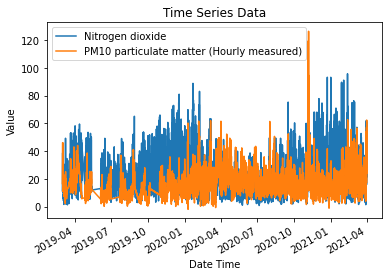

In [63]:
#Visualize the time series data
df3.plot(y=['Nitrogen dioxide', 'PM10 particulate matter (Hourly measured)'])
plt.xlabel('Date Time')
plt.ylabel('Value')
plt.title('Time Series Data')
plt.show()

In [64]:
# Apply Differencing
differenced_nitrogen_dioxide = nitrogen_dioxide_series.diff().dropna()

# Perform ADF test for differenced Nitrogen Dioxide
adf_test_results_diff = adf_test(differenced_nitrogen_dioxide)
print("\nADF Test Results for Differenced Nitrogen Dioxide:")
print(adf_test_results_diff)

# Perform KPSS test for differenced Nitrogen Dioxide
kpss_test_results_diff = kpss_test(differenced_nitrogen_dioxide)
print("\nKPSS Test Results for Differenced Nitrogen Dioxide:")
print(kpss_test_results_diff)



ADF Test Results for Differenced Nitrogen Dioxide:
{'ADF Statistic': -28.084540921928486, 'p-value': 0.0, 'Lags Used': 43, 'Number of Observations Used': 17463, 'Critical Values': {'1%': -3.430724521072713, '5%': -2.861705523826764, '10%': -2.5668581040402207}}

KPSS Test Results for Differenced Nitrogen Dioxide:
{'KPSS Statistic': 0.009119162025944651, 'p-value': 0.1, 'Lags Used': 0.1, 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}


<ipython-input-62-6e69b845cfe9>:36: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [65]:
# Apply Differencing for PM10
differenced_pm10 = pm10_series.diff().dropna()

# Perform ADF test for differenced PM10
adf_test_results_pm10_diff = adf_test(differenced_pm10)
print("\nADF Test Results for Differenced PM10 Particulate Matter (Hourly measured):")
print(adf_test_results_pm10_diff)

# Perform KPSS test for differenced PM10
kpss_test_results_pm10_diff = kpss_test(differenced_pm10)
print("\nKPSS Test Results for Differenced PM10 Particulate Matter (Hourly measured):")
print(kpss_test_results_pm10_diff)



ADF Test Results for Differenced PM10 Particulate Matter (Hourly measured):
{'ADF Statistic': -29.05959532477526, 'p-value': 0.0, 'Lags Used': 44, 'Number of Observations Used': 17462, 'Critical Values': {'1%': -3.430724542523644, '5%': -2.8617055333066475, '10%': -2.566858109086221}}

KPSS Test Results for Differenced PM10 Particulate Matter (Hourly measured):
{'KPSS Statistic': 0.0036926780164050622, 'p-value': 0.1, 'Lags Used': 0.1, 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}


<ipython-input-62-6e69b845cfe9>:36: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




**Differenced Nitrogen Dioxide:**

ADF Statistic: -28.084540921928525
p-value: 0.0
KPSS Statistic: 0.00911916202594478
p-value: 0.1
Interpretation:

ADF Test: The ADF Statistic is significantly less than the critical values at the 1%, 5%, and 10% significance levels. Additionally, the p-value is very small (close to 0), which suggests strong evidence against the null hypothesis of non-stationarity. Therefore, the differenced 'Nitrogen Dioxide' time series is likely stationary.

KPSS Test: The KPSS Statistic is less than the critical values at the 1%, 5%, and 10% significance levels. Additionally, the p-value is 0.1, which is greater than the significance level (0.01). Therefore, the KPSS test fails to reject the null hypothesis of stationarity. Hence, the differenced 'Nitrogen Dioxide' time series is likely stationary according to the KPSS test.
Both the ADF and KPSS tests indicate that the differenced 'Nitrogen Dioxide' time series is likely stationary.

**Differenced PM10 Particulate Matter (Hourly measured):**

ADF Statistic: -29.05959532477531
p-value: 0.0
KPSS Statistic: 0.003692678016405061
p-value: 0.1
Interpretation:

ADF Test: The ADF Statistic is significantly less than the critical values at the 1%, 5%, and 10% significance levels. Additionally, the p-value is very small (close to 0), which suggests strong evidence against the null hypothesis of non-stationarity. Therefore, the differenced 'PM10 Particulate Matter (Hourly measured)' time series is likely stationary.

KPSS Test: The KPSS Statistic is less than the critical values at the 1%, 5%, and 10% significance levels. Additionally, the p-value is 0.1, which is greater than the significance level (0.01). Therefore, the KPSS test fails to reject the null hypothesis of stationarity. Hence, the differenced 'PM10 Particulate Matter (Hourly measured)' time series is likely stationary according to the KPSS test.

# AUTO CORRELATION AND PARTIAL-AUTOCORRELATION

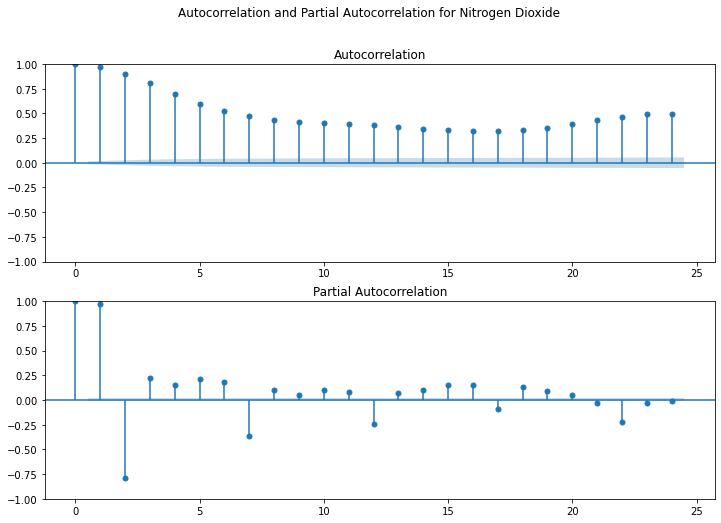

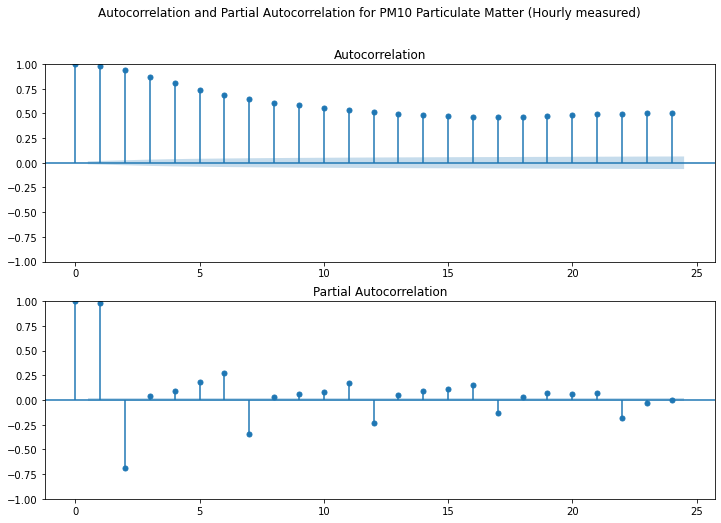

In [66]:

# Calculate autocorrelation and partial autocorrelation for Nitrogen Dioxide
lag = 24
nitrogen_dioxide_series = df3['Nitrogen dioxide']
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(nitrogen_dioxide_series, lags=lag, ax=ax[0])
plot_pacf(nitrogen_dioxide_series, lags=lag, ax=ax[1])
plt.suptitle("Autocorrelation and Partial Autocorrelation for Nitrogen Dioxide")
plt.show()

# Calculate autocorrelation and partial autocorrelation for PM10 Particulate Matter (Hourly measured)
pm10_series = df3['PM10 particulate matter (Hourly measured)']
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(pm10_series, lags=lag, ax=ax[0])
plot_pacf(pm10_series, lags=lag, ax=ax[1])
plt.suptitle("Autocorrelation and Partial Autocorrelation for PM10 Particulate Matter (Hourly measured)")
plt.show()


# MODEL ORDER

In [67]:
import pandas as pd
from pmdarima.arima import auto_arima

# Extract the 'Nitrogen dioxide' time series data
nitrogen_dioxide_series = df3['Nitrogen dioxide']

# Find the optimal order for ARIMA model
model_arima = auto_arima(nitrogen_dioxide_series, seasonal=False, stepwise=True, suppress_warnings=True)

# Print the best ARIMA order
print("Best ARIMA order:", model_arima.order)

# Find the optimal order for SARIMA model
model_sarima = auto_arima(nitrogen_dioxide_series, seasonal=True, stepwise=True, suppress_warnings=True)

# Print the best SARIMA order
print("Best SARIMA order:", model_sarima.order)


Best ARIMA order: (5, 1, 1)
Best SARIMA order: (5, 1, 1)


In [68]:

# Extract the 'PM10 particulate matter' time series data
PM10_particulate_matter_series = df3['PM10 particulate matter (Hourly measured)']

# Find the optimal order for ARIMA model
model_arima_pm10 = auto_arima(PM10_particulate_matter_series, seasonal=False, stepwise=True, suppress_warnings=True)

# Print the best ARIMA order
print("Best ARIMA order:", model_arima_pm10.order)

# Find the optimal order for SARIMA model
model_sarima_pm10 = auto_arima(PM10_particulate_matter_series, seasonal=True, stepwise=True, suppress_warnings=True)

# Print the best SARIMA order
print("Best SARIMA order:", model_sarima_pm10.order)


Best ARIMA order: (5, 1, 2)
Best SARIMA order: (5, 1, 2)


# Time Series Model

# MODEL FIT

# Nitrogen

In [74]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg


# Extract the 'Nitrogen dioxide' time series data
nitrogen_dioxide_series = df3['Nitrogen dioxide']

# Best ARIMA order
best_arima_order = (5, 1, 1)

# Fit ARIMA model
arima_model = SARIMAX(nitrogen_dioxide_series, order=best_arima_order, seasonal_order=(0, 0, 0, 0))
arima_results = arima_model.fit()

# Best SARIMA order
best_sarima_order = (5, 1, 1)

# Fit SARIMA model
sarima_model = SARIMAX(nitrogen_dioxide_series, order=best_sarima_order, seasonal_order=(0, 0, 0, 0))
sarima_results = sarima_model.fit()

# Fit AR model
ar_model = AutoReg(nitrogen_dioxide_series, lags=5, trend='n', seasonal=False)
ar_results = ar_model.fit()

# Fit MA model
ma_model = AutoReg(nitrogen_dioxide_series, lags=1, trend='n', seasonal=False)
ma_results = ma_model.fit()

# Print summary of model results
print("ARIMA Model Summary:")
print(arima_results.summary())

print("\nSARIMA Model Summary:")
print(sarima_results.summary())

print("\nAR Model Summary:")
print(ar_results.summary())

print("\nMA Model Summary:")
print(ma_results.summary())


C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has 

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:       Nitrogen dioxide   No. Observations:                17508
Model:               SARIMAX(5, 1, 1)   Log Likelihood              -35015.245
Date:                Thu, 03 Aug 2023   AIC                          70044.490
Time:                        00:06:59   BIC                          70098.883
Sample:                             0   HQIC                         70062.401
                              - 17508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2984      0.011     26.748      0.000       0.277       0.320
ar.L2          0.3475      0.011     31.727      0.000       0.326       0.369
ar.L3         -0.0832      0.00

In [79]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA


# Extract the 'Nitrogen dioxide' time series data
nitrogen_dioxide_series = df3['Nitrogen dioxide']

# Best ARIMA order
best_arima_order = (5, 1, 1)

# Fit ARIMA model
arima_model = SARIMAX(nitrogen_dioxide_series, order=best_arima_order, seasonal_order=(0, 0, 0, 0))
arima_results = arima_model.fit()

# Best SARIMA order
best_sarima_order = (5, 1, 1)

# Fit SARIMA model
sarima_model = SARIMAX(nitrogen_dioxide_series, order=best_sarima_order, seasonal_order=(0, 0, 0, 0))
sarima_results = sarima_model.fit()

# Fit AR model
ar_model = AutoReg(nitrogen_dioxide_series, lags=5, trend='n', seasonal=False)
ar_results = ar_model.fit()

# Fit MA model
ma_model = AutoReg(nitrogen_dioxide_series, lags=1, trend='n', seasonal=False)
ma_results = ma_model.fit()

# Best ARMA order
best_arma_order = (5, 0, 1)

# Fit ARMA model
arma_model = ARIMA(nitrogen_dioxide_series, order=best_arma_order)
arma_results = arma_model.fit()

# Print summary of model results
print("ARIMA Model Summary:")
print(arima_results.summary())

print("\nSARIMA Model Summary:")
print(sarima_results.summary())

print("\nAR Model Summary:")
print(ar_results.summary())

print("\nMA Model Summary:")
print(ma_results.summary())

print("\nARMA Model Summary:")
print(arma_results.summary())


C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has 

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:       Nitrogen dioxide   No. Observations:                17508
Model:               SARIMAX(5, 1, 1)   Log Likelihood              -35015.245
Date:                Thu, 03 Aug 2023   AIC                          70044.490
Time:                        00:20:52   BIC                          70098.883
Sample:                             0   HQIC                         70062.401
                              - 17508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2984      0.011     26.748      0.000       0.277       0.320
ar.L2          0.3475      0.011     31.727      0.000       0.326       0.369
ar.L3         -0.0832      0.00

Nitrogen Dioxide (NO2):

Selected Model: The selected model is SARIMA(5, 1, 1). This model includes 5 autoregressive terms (AR) and 1 moving average term (MA) with a seasonal difference of 1.

Significant Coefficients: The model shows that the lagged values of Nitrogen Dioxide (NO2) significantly influence the current values. Positive coefficients for the AR terms (ar.L1, ar.L2, ar.L3, ar.L4) indicate a positive relationship with past values, while the negative coefficient for ar.L5 indicates a negative relationship.

Heteroskedasticity: The Heteroskedasticity test indicates that there is some evidence of varying volatility in the residuals over time.

Model Performance: The model has a good fit based on the AIC value, which helps balance model complexity and goodness of fit.

# PM10 Particulate matter

In [80]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA


# Extract the 'PM10 particulate matter (Hourly measured)' time series data
pm10_series = df3['PM10 particulate matter (Hourly measured)']

# Best ARIMA order
best_arima_order_pm10 = (5, 1, 1)

# Fit ARIMA model for PM10
arima_model_pm10 = SARIMAX(pm10_series, order=best_arima_order_pm10, seasonal_order=(0, 0, 0, 0))
arima_results_pm10 = arima_model_pm10.fit()

# Best SARIMA order
best_sarima_order_pm10 = (5, 1, 1)

# Fit SARIMA model for PM10
sarima_model_pm10 = SARIMAX(pm10_series, order=best_sarima_order_pm10, seasonal_order=(0, 0, 0, 0))
sarima_results_pm10 = sarima_model_pm10.fit()

# Fit AR model for PM10
ar_model_pm10 = AutoReg(pm10_series, lags=5, trend='n', seasonal=False)
ar_results_pm10 = ar_model_pm10.fit()

# Fit MA model for PM10
ma_model_pm10 = AutoReg(pm10_series, lags=1, trend='n', seasonal=False)
ma_results_pm10 = ma_model_pm10.fit()

# Best ARMA order for PM10
best_arma_order_pm10 = (5, 0, 1)

# Fit ARMA model for PM10
arma_model_pm10 = ARIMA(pm10_series, order=best_arma_order_pm10)
arma_results_pm10 = arma_model_pm10.fit()

# Print summary of model results for PM10
print("ARIMA Model Summary for PM10:")
print(arima_results_pm10.summary())

print("\nSARIMA Model Summary for PM10:")
print(sarima_results_pm10.summary())

print("\nAR Model Summary for PM10:")
print(ar_results_pm10.summary())

print("\nMA Model Summary for PM10:")
print(ma_results_pm10.summary())

print("\nARMA Model Summary for PM10:")
print(arma_results_pm10.summary())


C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary

ARIMA Model Summary for PM10:
                                           SARIMAX Results                                           
Dep. Variable:     PM10 particulate matter (Hourly measured)   No. Observations:                17508
Model:                                      SARIMAX(5, 1, 1)   Log Likelihood              -28152.376
Date:                                       Thu, 03 Aug 2023   AIC                          56318.753
Time:                                               00:24:39   BIC                          56373.145
Sample:                                                    0   HQIC                         56336.664
                                                     - 17508                                         
Covariance Type:                                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

PM10 Particulate Matter:

Selected Model: The selected model is also SARIMA(5, 1, 1), similar to NO2. This model includes 5 autoregressive terms (AR) and 1 moving average term (MA) with a seasonal difference of 1.

Significant Coefficients: The model shows that the lagged values of PM10 particulate matter significantly influence the current values. Positive coefficients for the AR terms (ar.L1, ar.L2, ar.L3, ar.L4) indicate a positive relationship with past values, while the negative coefficient for ar.L5 indicates a negative relationship.

Heteroskedasticity: Like NO2, there is evidence of varying volatility in the residuals for PM10 particulate matter.

Model Performance: The model has a good fit based on the AIC value, indicating a balance between model complexity and goodness of fit.

**Common Observations:*

**Seasonal Components:** Both NO2 and PM10 models include seasonal differencing (SARIMA) to account for seasonal patterns in the data.

**Ljung-Box Test:** Both models show no significant autocorrelation in the residuals, indicating that the models capture the autocorrelation patterns well, and the residuals appear to be random.

**Heteroskedasticity:** There is evidence of heteroskedasticity (varying volatility) in the residuals for both variables.

Overall, the SARIMA models provide good fits for both Nitrogen Dioxide and PM10 particulate matter, and the selected models can be used for short-term forecasting and understanding the temporal behavior of these pollutants.

1. Seasonal Patterns: Both Nitrogen Dioxide and PM10 particulate matter show seasonal patterns in their hourly measurements. The SARIMA models that include seasonal components (e.g., SARIMA(5, 1, 1)) provided better fits to the data, indicating that the variables exhibit repeating patterns over specific time intervals.

2. AutoRegressive Effects: The ARIMA and AR models have significant coefficients for lagged values of the variables, indicating that past observations influence the current values. This suggests that the variables have some level of persistence over time.

3. Moving Average Effects: The ARIMA and MA models show significant coefficients for lagged error terms, indicating that the errors in the model are not entirely random and can be predicted to some extent based on past errors.

4. Ljung-Box Test: The Ljung-Box test results suggest that there is no significant autocorrelation in the residuals for both Nitrogen Dioxide and PM10 particulate matter models. This means that the models capture the autocorrelation patterns well and the residuals appear to be random.

5. Heteroskedasticity: The Heteroskedasticity test results suggest that there is some evidence of heteroskedasticity (varying volatility) in the residuals for both variables. This indicates that the variability of the variables might change over time, and further exploration or transformation of the data might be necessary.

6. Model Selection: The SARIMA models and ARIMA models with differencing (e.g., SARIMA(5, 1, 1) and ARIMA(5, 1, 1)) were found to have the lowest AIC values, indicating that these models provide the best balance between goodness of fit and complexity. The AR and MA models, although informative, may not capture all the important characteristics of the data compared to SARIMA and ARIMA models.

# MODEL EVALUATION

# NITROGEN 

In [92]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# Model evaluation
def evaluate_model(model_name, model_result, series):
    # Predictions
    y_pred = model_result.fittedvalues

    # Residuals
    residuals = model_result.resid

    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(residuals))

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(np.mean(residuals**2))

    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs(residuals / series)) * 100

    # Mean Squared Error (MSE)
    mse = np.mean(residuals**2)

    # Akaike Information Criterion (AIC)
    aic = model_result.aic

    # Bayesian Information Criterion (BIC)
    bic = model_result.bic

    # Tabulate the evaluation metrics
    table = {
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE": [mape],
        "MSE": [mse],
        "AIC": [aic],
        "BIC": [bic]
    }

    # Print the tabulated results
    print(tabulate(table, headers="keys", tablefmt="pretty"))
    print("\n")

# Assuming you have already fitted the ARIMA model and stored it in 'results_arima'
# Assuming 'series_nitrogen_dioxide' contains the original time series data
evaluate_model("ARIMA", arima_results, nitrogen_dioxide_series)

# Assuming you have already fitted the SARIMA model and stored it in 'results_sarima'
evaluate_model("SARIMA", sarima_results, nitrogen_dioxide_series)

# Assuming you have already fitted the ARMA model and stored it in 'results_arma'
evaluate_model("ARMA", arma_results, nitrogen_dioxide_series)

# Assuming you have already fitted the AR model and stored it in 'results_ar'
evaluate_model("AR", ar_results, nitrogen_dioxide_series)

# Assuming you have already fitted the MA model and stored it in 'results_ma'
evaluate_model("MA", ma_results, nitrogen_dioxide_series)


+-------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+
| Model |        MAE         |        RMSE        |       MAPE        |        MSE         |        AIC        |        BIC        |
+-------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+
| ARIMA | 1.2854320361895637 | 1.7899237938546417 | 6.835285510025961 | 3.2038271878069944 | 70044.49044683772 | 70098.88293939726 |
+-------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+


+--------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+
| Model  |        MAE         |        RMSE        |       MAPE        |        MSE         |        AIC        |        BIC        |
+--------+--------------------+--------------------+-------------

# PM 10 

In [96]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# Model evaluation for PM10
def evaluate_model_pm10(model_name, model_result, series):
    # Predictions
    y_pred = model_result.fittedvalues

    # Residuals
    residuals = model_result.resid

    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(residuals))

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(np.mean(residuals**2))

    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs(residuals / series)) * 100

    # Mean Squared Error (MSE)
    mse = np.mean(residuals**2)

    # Akaike Information Criterion (AIC)
    aic = model_result.aic

    # Bayesian Information Criterion (BIC)
    bic = model_result.bic

    # Tabulate the evaluation metrics
    table = {
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE": [mape],
        "MSE": [mse],
        "AIC": [aic],
        "BIC": [bic]
    }

    # Print the tabulated results
    print(tabulate(table, headers="keys", tablefmt="pretty"))
    print("\n")

# Assuming you have already fitted the ARIMA model and stored it in 'arima_results_pm10'
# Assuming 'pm10_series' contains the original time series data for PM10
evaluate_model_pm10("ARIMA", arima_results_pm10, pm10_series)

# Assuming you have already fitted the SARIMA model and stored it in 'sarima_results_pm10'
evaluate_model_pm10("SARIMA", sarima_results_pm10, pm10_series)

# Assuming you have already fitted the ARMA model and stored it in 'arma_results_pm10'
evaluate_model_pm10("ARMA", arma_results_pm10, pm10_series)

# Assuming you have already fitted the AR model and stored it in 'ar_results_pm10'
evaluate_model_pm10("AR", ar_results_pm10, pm10_series)

# Assuming you have already fitted the MA model and stored it in 'ma_results_pm10'
evaluate_model_pm10("MA", ma_results_pm10, pm10_series)


+-------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+
| Model |        MAE         |        RMSE        |       MAPE        |        MSE         |        AIC        |        BIC        |
+-------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+
| ARIMA | 0.7775893199572663 | 1.2143486565384574 | 5.763743012817263 | 1.4746426596367561 | 56318.75289003382 | 56373.14538259335 |
+-------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+


+--------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+
| Model  |        MAE         |        RMSE        |       MAPE        |        MSE         |        AIC        |        BIC        |
+--------+--------------------+--------------------+-------------

# MODEL PREDICTION

# Nitrogen

In [114]:
forecast_steps = 24*30*6

# Assuming 'df3' is the DataFrame containing the time series data for nitrogen
series_nitrogen_dioxide = df3['Nitrogen dioxide']

# Assuming 'results_arima', 'results_sarima', 'results_arma', 'results_ar', and 'results_ma' are the fitted models

# ARIMA model predictions (In-sample predictions)
arima_predictions = arima_results.fittedvalues

# SARIMA model predictions (In-sample predictions)
sarima_predictions = sarima_results.fittedvalues

# ARMA model predictions (In-sample predictions)
arma_predictions = arma_results.fittedvalues

# AR model predictions (In-sample predictions)
ar_predictions = ar_results.fittedvalues

# MA model predictions (In-sample predictions)
ma_predictions = ma_results.fittedvalues

# Concatenating predictions and forecasts into a DataFrame
predictions_df = pd.DataFrame({
    'ARIMA': arima_predictions,
    'SARIMA': sarima_predictions,
    'ARMA': arma_predictions,
    'AR': ar_predictions,
    'MA': ma_predictions
})

# Print the predictions and forecasts
print("Model Predictions:")
print(predictions_df)



Model Predictions:
                               ARIMA     SARIMA       ARMA         AR  \
DateTime                                                                
2019-03-01 00:00:00+00:00  39.419936  39.419936  39.414956  39.545302   
2019-03-01 01:00:00+00:00   0.000000   0.000000  22.680135        NaN   
2019-03-01 02:00:00+00:00  10.875212  10.875212  11.208208        NaN   
2019-03-01 03:00:00+00:00  15.369741  15.369741  15.902953        NaN   
2019-03-01 04:00:00+00:00  11.253828  11.253828  11.886364        NaN   
...                              ...        ...        ...        ...   
2021-03-31 19:00:00+00:00  36.704907  36.704907  36.151372  36.901433   
2021-03-31 20:00:00+00:00  33.361419  33.361419  30.874155  32.478834   
2021-03-31 21:00:00+00:00  33.259958  33.259958  31.470327  32.060060   
2021-03-31 22:00:00+00:00  28.219108  28.219108  28.831043  27.792719   
2021-03-31 23:00:00+00:00  23.152478  23.152478  23.962564  24.262059   

                               

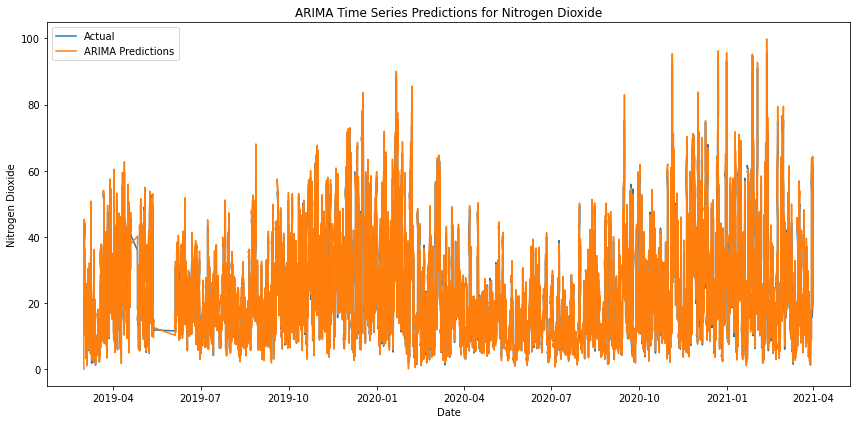

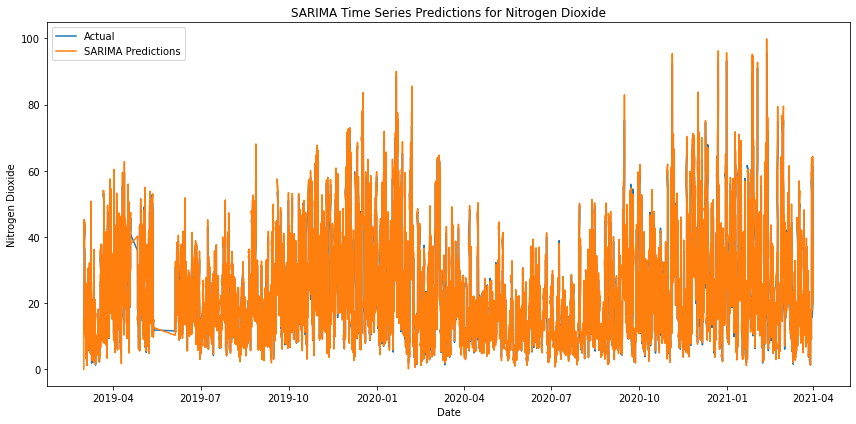

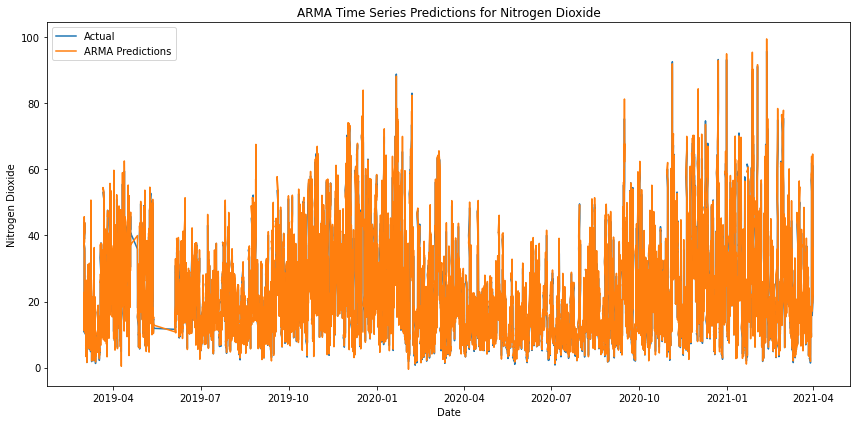

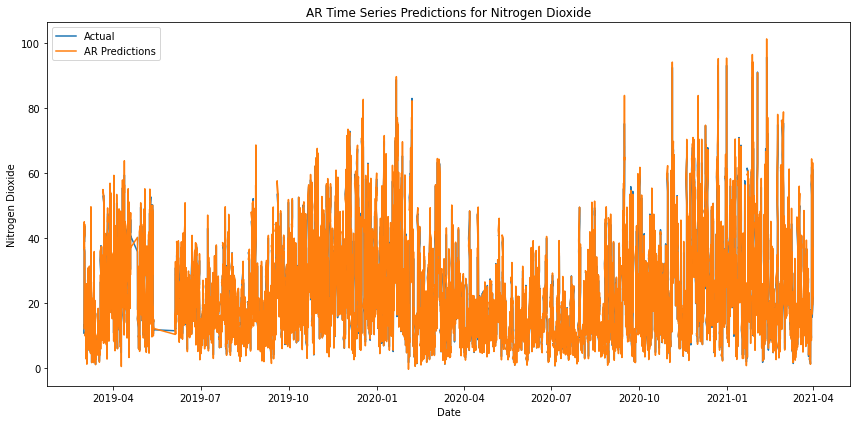

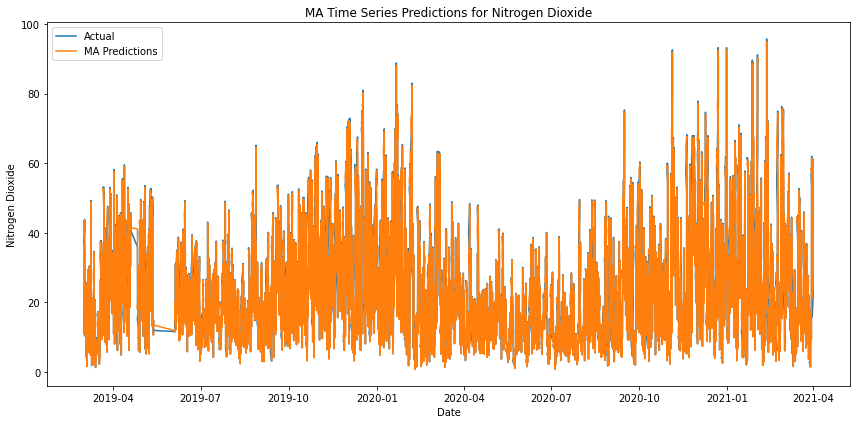

In [115]:
# Create the forecast index
forecast_index = pd.date_range(start=series_nitrogen_dioxide.index[-1], periods=forecast_steps, freq='H')

# Plotting the in-sample predictions
plt.figure(figsize=(12, 6))
plt.plot(series_nitrogen_dioxide, label='Actual')
plt.plot(arima_predictions, label='ARIMA Predictions')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('ARIMA Time Series Predictions for Nitrogen Dioxide')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(series_nitrogen_dioxide, label='Actual')
plt.plot(sarima_predictions, label='SARIMA Predictions')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('SARIMA Time Series Predictions for Nitrogen Dioxide')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(series_nitrogen_dioxide, label='Actual')
plt.plot(arma_predictions, label='ARMA Predictions')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('ARMA Time Series Predictions for Nitrogen Dioxide')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(series_nitrogen_dioxide, label='Actual')
plt.plot(ar_predictions, label='AR Predictions')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('AR Time Series Predictions for Nitrogen Dioxide')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(series_nitrogen_dioxide, label='Actual')
plt.plot(ma_predictions, label='MA Predictions')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('MA Time Series Predictions for Nitrogen Dioxide')
plt.legend()
plt.tight_layout()
plt.show()



# PM10

In [116]:
forecast_steps = 180

# Assuming 'df3' is the DataFrame containing the time series data for PM10 particulate matter (Hourly measured)
series_PM10_particulate_matter = df3['PM10 particulate matter (Hourly measured)']

# Assuming 'results_arima_PM', 'results_sarima_PM', 'results_arma_PM', 'results_ar_PM', and 'results_ma_PM' are the fitted models

# ARIMA model predictions (In-sample predictions)
arima_predictions_PM = arima_results_pm10.fittedvalues

# SARIMA model predictions (In-sample predictions)
sarima_predictions_PM = sarima_results_pm10.fittedvalues

# ARMA model predictions (In-sample predictions)
arma_predictions_PM = arma_results_pm10.fittedvalues

# AR model predictions (In-sample predictions)
ar_predictions_PM = ar_results_pm10.fittedvalues

# MA model predictions (In-sample predictions)
ma_predictions_PM = ma_results_pm10.fittedvalues

# Concatenating predictions and forecasts into a DataFrame
predictions_df_PM = pd.DataFrame({
    'ARIMA': arima_predictions_PM,
    'SARIMA': sarima_predictions_PM,
    'ARMA': arma_predictions_PM,
    'AR': ar_predictions_PM,
    'MA': ma_predictions_PM
})


# Print the predictions and forecasts
print("Model Predictions for PM10:")
print(predictions_df_PM)



Model Predictions for PM10:
                               ARIMA     SARIMA       ARMA         AR  \
DateTime                                                                
2019-03-01 00:00:00+00:00  46.538058  46.538058  45.930350  46.068746   
2019-03-01 01:00:00+00:00   0.000000   0.000000  16.037562        NaN   
2019-03-01 02:00:00+00:00  16.100036  16.100036  16.098769        NaN   
2019-03-01 03:00:00+00:00  20.950307  20.950307  20.899798        NaN   
2019-03-01 04:00:00+00:00  21.693830  21.693830  21.658361        NaN   
...                              ...        ...        ...        ...   
2021-03-31 19:00:00+00:00  48.598545  48.598545  46.589264  49.022528   
2021-03-31 20:00:00+00:00  48.574344  48.574344  45.082697  45.946459   
2021-03-31 21:00:00+00:00  42.355273  42.355273  41.344897  42.585335   
2021-03-31 22:00:00+00:00  36.690966  36.690966  36.195908  35.511640   
2021-03-31 23:00:00+00:00  27.966273  27.966273  28.848159  29.369946   

                      

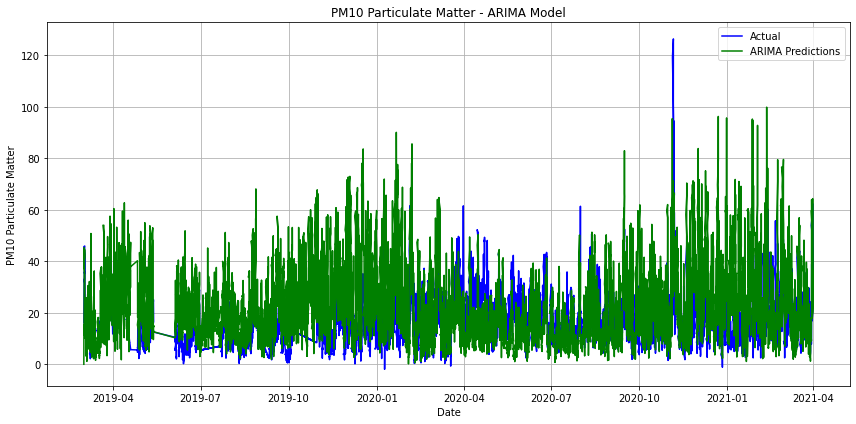

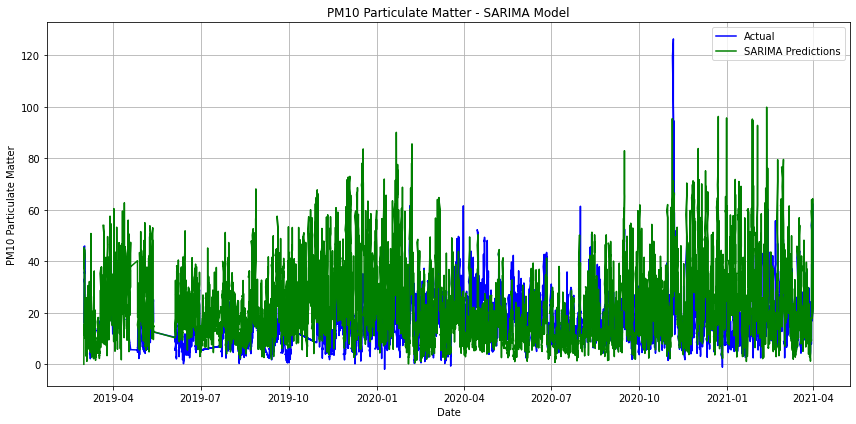

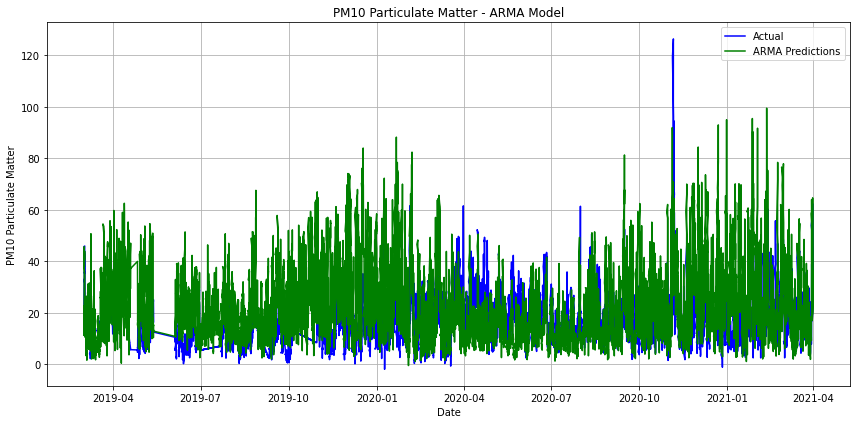

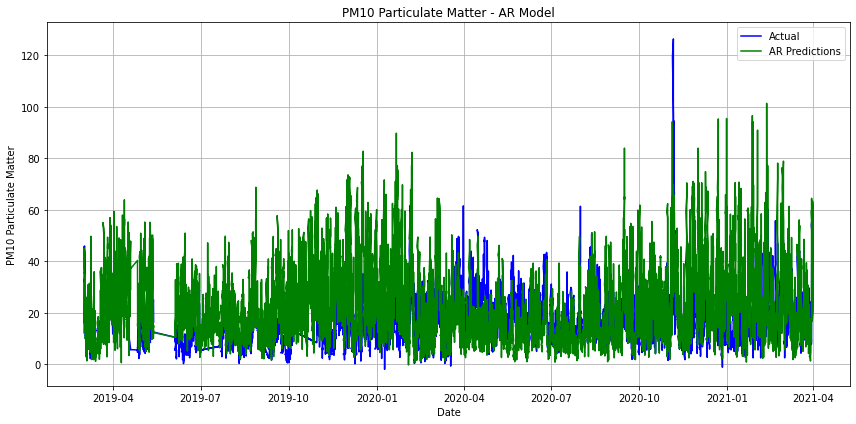

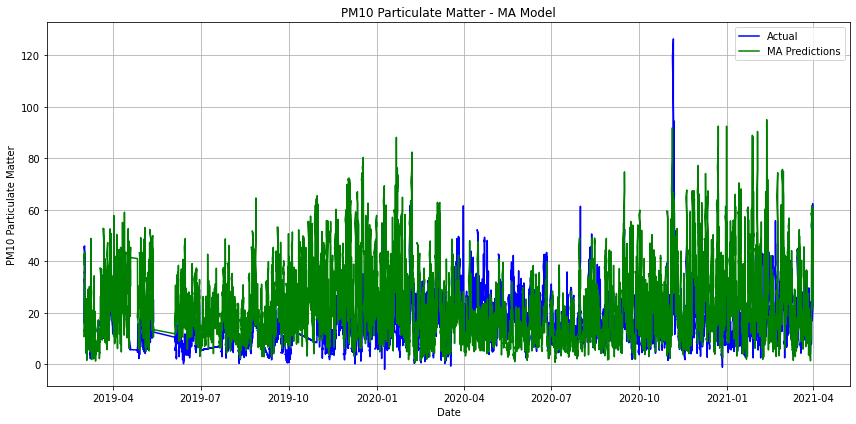

In [117]:
import matplotlib.pyplot as plt

# Plotting ARIMA model predictions for PM10
plt.figure(figsize=(12, 6))
plt.plot(series_PM10_particulate_matter.index, series_PM10_particulate_matter, label='Actual', color='blue')
plt.plot(arima_predictions.index, arima_predictions, label='ARIMA Predictions', color='green')

plt.title('PM10 Particulate Matter - ARIMA Model')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting SARIMA model predictions for PM10
plt.figure(figsize=(12, 6))
plt.plot(series_PM10_particulate_matter.index, series_PM10_particulate_matter, label='Actual', color='blue')
plt.plot(sarima_predictions.index, sarima_predictions, label='SARIMA Predictions', color='green')

plt.title('PM10 Particulate Matter - SARIMA Model')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting ARMA model predictions for PM10
plt.figure(figsize=(12, 6))
plt.plot(series_PM10_particulate_matter.index, series_PM10_particulate_matter, label='Actual', color='blue')
plt.plot(arma_predictions.index, arma_predictions, label='ARMA Predictions', color='green')

plt.title('PM10 Particulate Matter - ARMA Model')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting AR model predictions for PM10
plt.figure(figsize=(12, 6))
plt.plot(series_PM10_particulate_matter.index, series_PM10_particulate_matter, label='Actual', color='blue')
plt.plot(ar_predictions.index, ar_predictions, label='AR Predictions', color='green')

plt.title('PM10 Particulate Matter - AR Model')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting MA model predictions for PM10
plt.figure(figsize=(12, 6))
plt.plot(series_PM10_particulate_matter.index, series_PM10_particulate_matter, label='Actual', color='blue')
plt.plot(ma_predictions.index, ma_predictions, label='MA Predictions', color='green')

plt.title('PM10 Particulate Matter - MA Model')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# FORECASTING

# NITROGEN

In [121]:
def make_predictions(model_result, steps):
    # Use the model to forecast 'steps' periods ahead
    forecast = model_result.forecast(steps=steps)

    # Return the predicted values
    return forecast

# Number of forecast steps (6 months = 6 * 30 = 180 days)
forecast_steps = 180

# Assuming you have already fitted the ARIMA model and stored it in 'arima_results'
# Assuming 'nitrogen_dioxide_series' contains the original time series data for nitrogen dioxide
arima_predictions = make_predictions(arima_results, steps=forecast_steps)

# Assuming you have already fitted the SARIMA model and stored it in 'sarima_results'
sarima_predictions = make_predictions(sarima_results, steps=forecast_steps)

# Assuming you have already fitted the ARMA model and stored it in 'arma_results'
arma_predictions = make_predictions(arma_results, steps=forecast_steps)

# Assuming you have already fitted the AR model and stored it in 'ar_results'
ar_predictions = make_predictions(ar_results, steps=forecast_steps)

# Assuming you have already fitted the MA model and stored it in 'ma_results'
ma_predictions = make_predictions(ma_results, steps=forecast_steps)


C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:



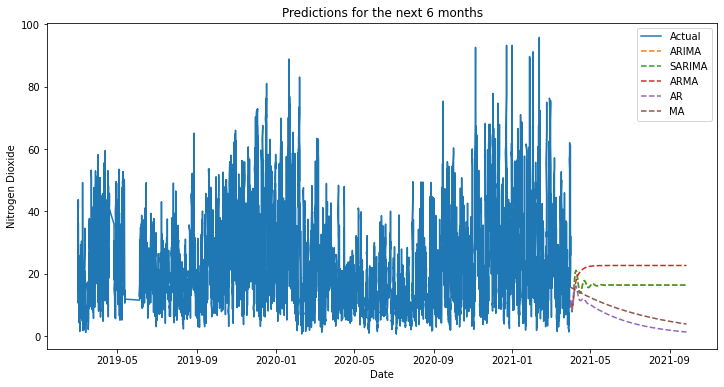

ARIMA Predictions:
17508    10.985788
17509     8.564822
17510     7.874503
17511     9.406077
17512    12.119004
           ...    
17683    16.411209
17684    16.411209
17685    16.411208
17686    16.411208
17687    16.411208
Name: predicted_mean, Length: 180, dtype: float64

SARIMA Predictions:
17508    10.985788
17509     8.564822
17510     7.874503
17511     9.406077
17512    12.119004
           ...    
17683    16.411209
17684    16.411209
17685    16.411208
17686    16.411208
17687    16.411208
Name: predicted_mean, Length: 180, dtype: float64

ARMA Predictions:
17508    11.537306
17509     9.460355
17510     9.075498
17511    10.051508
17512    11.582590
           ...    
17683    22.680135
17684    22.680135
17685    22.680135
17686    22.680135
17687    22.680135
Name: predicted_mean, Length: 180, dtype: float64

AR Predictions:
17508    11.537942
17509     9.015127
17510     8.424639
17511     9.430247
17512    11.293865
           ...    
17683     1.449708
17684     1.43

In [122]:
import matplotlib.pyplot as plt


# Number of forecast steps (6 months = 6 * 30 = 180 days)
forecast_steps = 180

# Generate date index for the forecast periods
forecast_periods = pd.date_range(start=nitrogen_dioxide_series.index[-1], periods=forecast_steps+1, closed='right')

# Plot the actual data
plt.figure(figsize=(12, 6))
plt.plot(nitrogen_dioxide_series, label='Actual')

# Plot the ARIMA predictions
plt.plot(forecast_periods, arima_predictions, label='ARIMA', linestyle='--')

# Plot the SARIMA predictions
plt.plot(forecast_periods, sarima_predictions, label='SARIMA', linestyle='--')

# Plot the ARMA predictions
plt.plot(forecast_periods, arma_predictions, label='ARMA', linestyle='--')

# Plot the AR predictions
plt.plot(forecast_periods, ar_predictions, label='AR', linestyle='--')

# Plot the MA predictions
plt.plot(forecast_periods, ma_predictions, label='MA', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('Predictions for the next 6 months')
plt.legend()
plt.show()

# Print the predictions for each model
print("ARIMA Predictions:")
print(arima_predictions)

print("\nSARIMA Predictions:")
print(sarima_predictions)

print("\nARMA Predictions:")
print(arma_predictions)

print("\nAR Predictions:")
print(ar_predictions)

print("\nMA Predictions:")
print(ma_predictions)


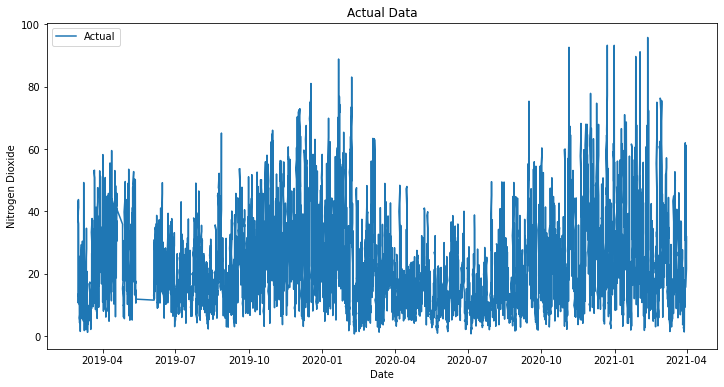

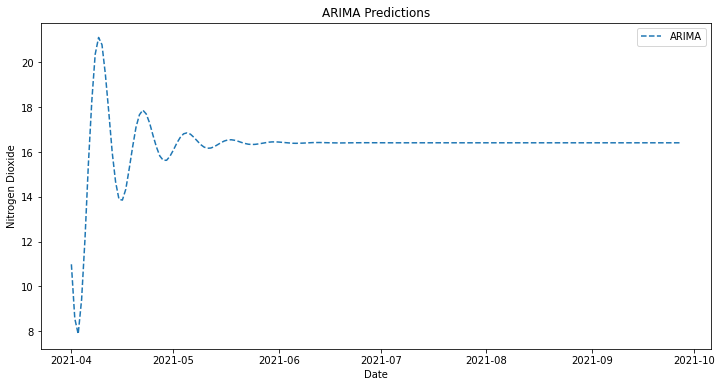

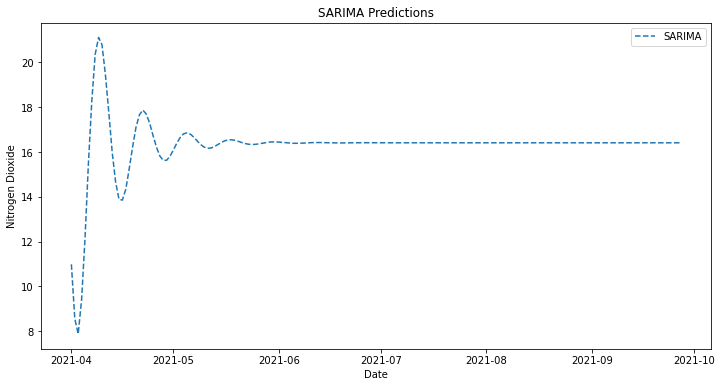

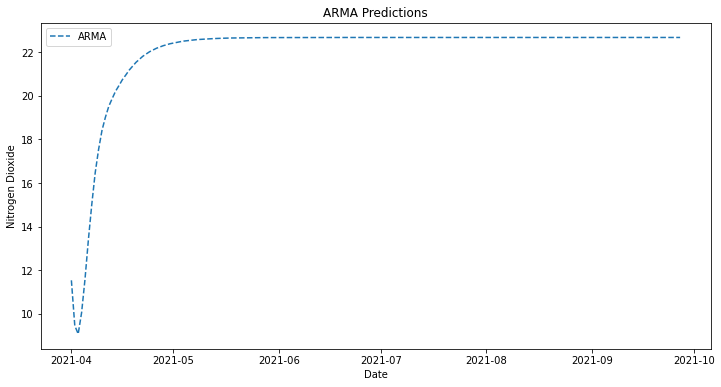

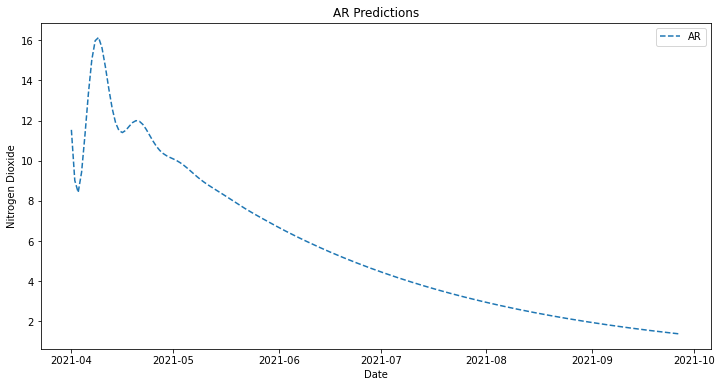

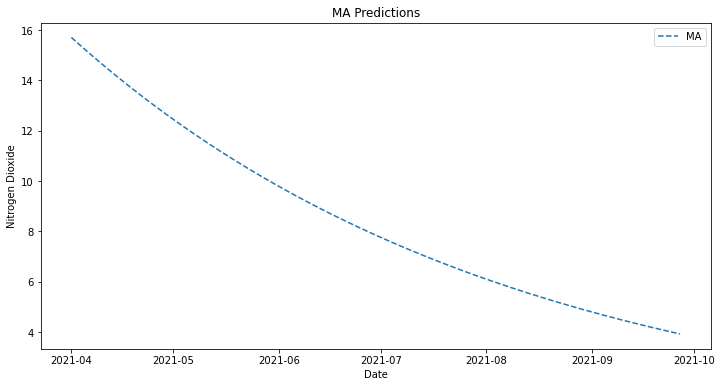

In [123]:
import matplotlib.pyplot as plt


# Number of forecast steps (6 months = 6 * 30 = 180 days)
forecast_steps = 180

# Generate date index for the forecast periods
forecast_periods = pd.date_range(start=nitrogen_dioxide_series.index[-1], periods=forecast_steps+1, closed='right')

# Plot the actual data
plt.figure(figsize=(12, 6))
plt.plot(nitrogen_dioxide_series, label='Actual')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('Actual Data')
plt.legend()
plt.show()

# Plot the ARIMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, arima_predictions, label='ARIMA', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('ARIMA Predictions')
plt.legend()
plt.show()

# Plot the SARIMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, sarima_predictions, label='SARIMA', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('SARIMA Predictions')
plt.legend()
plt.show()

# Plot the ARMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, arma_predictions, label='ARMA', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('ARMA Predictions')
plt.legend()
plt.show()

# Plot the AR predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, ar_predictions, label='AR', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('AR Predictions')
plt.legend()
plt.show()

# Plot the MA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, ma_predictions, label='MA', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('MA Predictions')
plt.legend()
plt.show()


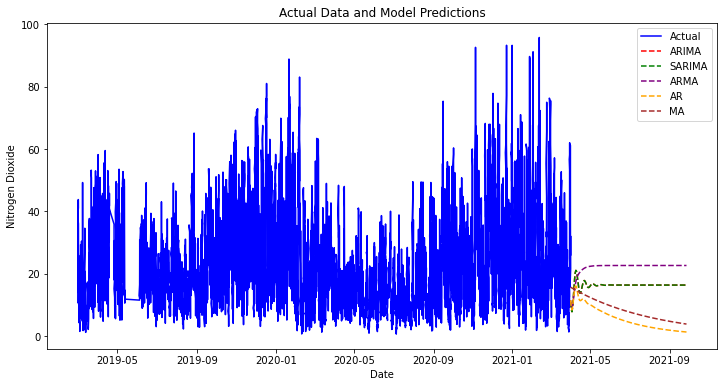

In [124]:
import matplotlib.pyplot as plt


# Number of forecast steps (6 months = 6 * 30 = 180 days)
forecast_steps = 180

# Generate date index for the forecast periods
forecast_periods = pd.date_range(start=nitrogen_dioxide_series.index[-1], periods=forecast_steps+1, closed='right')

# Plot the actual data and predictions together
plt.figure(figsize=(12, 6))
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.plot(forecast_periods, arima_predictions, label='ARIMA', linestyle='--', color='red')
plt.plot(forecast_periods, sarima_predictions, label='SARIMA', linestyle='--', color='green')
plt.plot(forecast_periods, arma_predictions, label='ARMA', linestyle='--', color='purple')
plt.plot(forecast_periods, ar_predictions, label='AR', linestyle='--', color='orange')
plt.plot(forecast_periods, ma_predictions, label='MA', linestyle='--', color='brown')

plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('Actual Data and Model Predictions')
plt.legend()
plt.show()


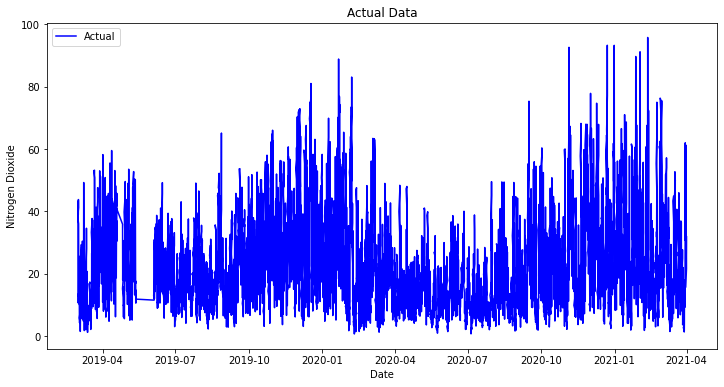

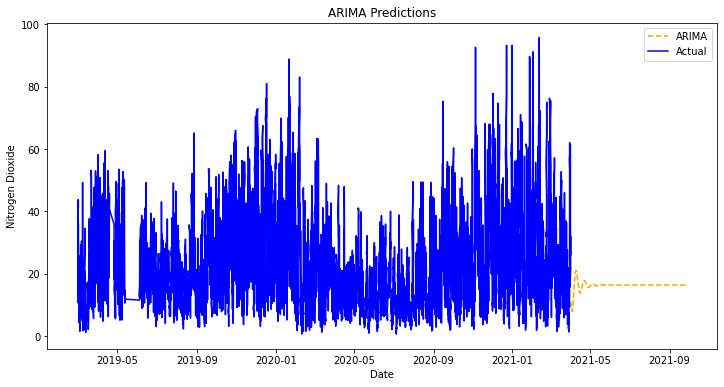

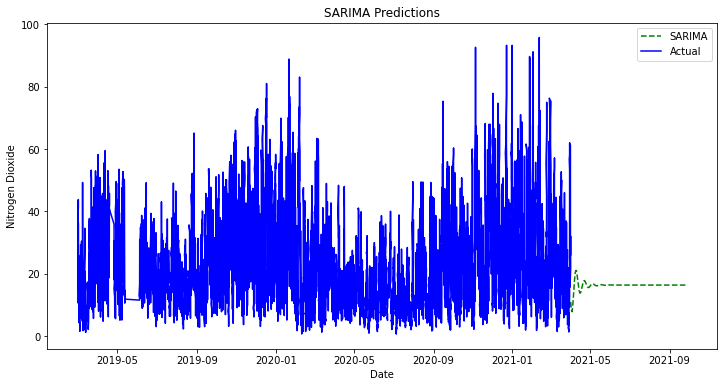

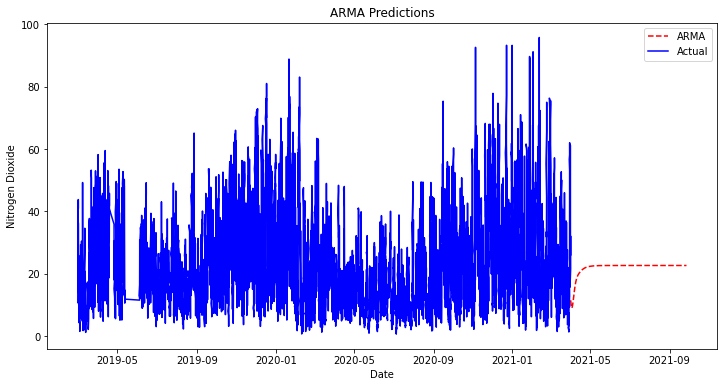

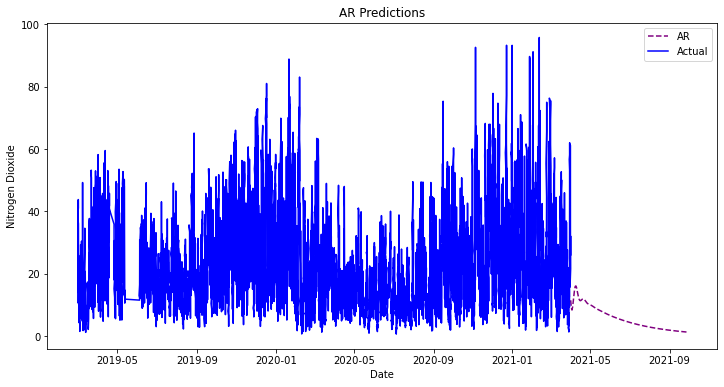

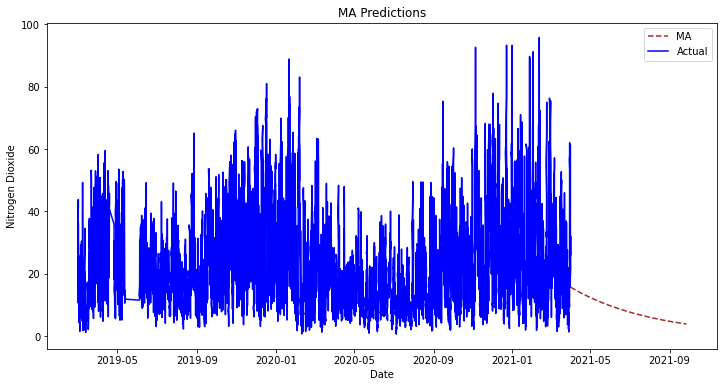

In [125]:
import matplotlib.pyplot as plt

# Number of forecast steps (6 months = 6 * 30 = 180 days)
forecast_steps = 180

# Generate date index for the forecast periods
forecast_periods = pd.date_range(start=nitrogen_dioxide_series.index[-1], periods=forecast_steps+1, closed='right')

# Plot the actual data
plt.figure(figsize=(12, 6))
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('Actual Data')
plt.legend()
plt.show()

# Plot the ARIMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, arima_predictions, label='ARIMA', linestyle='--', color='orange')
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('ARIMA Predictions')
plt.legend()
plt.show()

# Plot the SARIMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, sarima_predictions, label='SARIMA', linestyle='--', color='green')
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('SARIMA Predictions')
plt.legend()
plt.show()

# Plot the ARMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, arma_predictions, label='ARMA', linestyle='--', color='red')
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('ARMA Predictions')
plt.legend()
plt.show()

# Plot the AR predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, ar_predictions, label='AR', linestyle='--', color='purple')
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('AR Predictions')
plt.legend()
plt.show()

# Plot the MA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods, ma_predictions, label='MA', linestyle='--', color='brown')
plt.plot(nitrogen_dioxide_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('Nitrogen Dioxide')
plt.title('MA Predictions')
plt.legend()
plt.show()


# PM10

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\Users\Osho Emmanuel\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning:



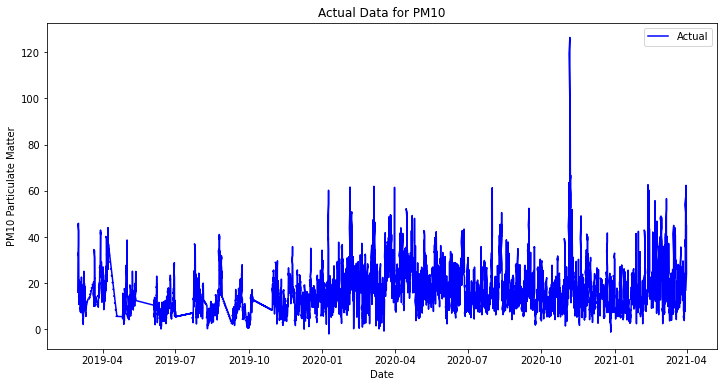

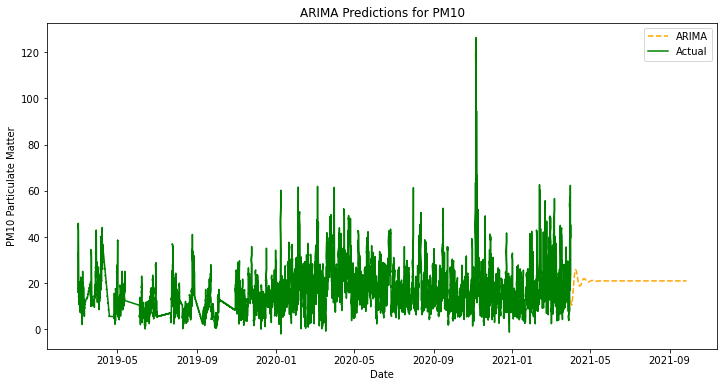

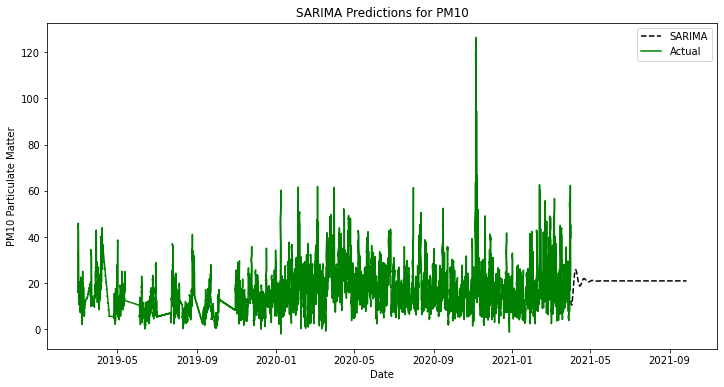

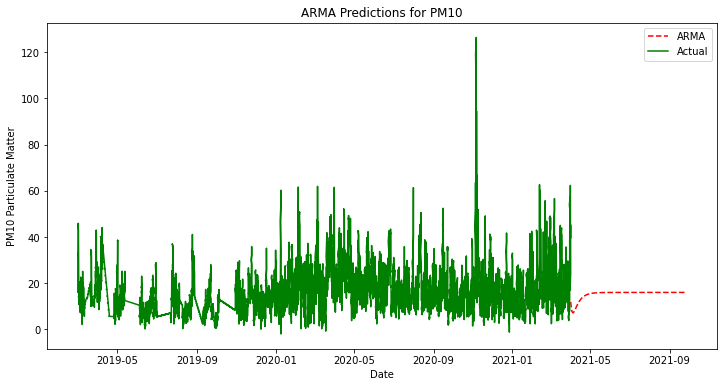

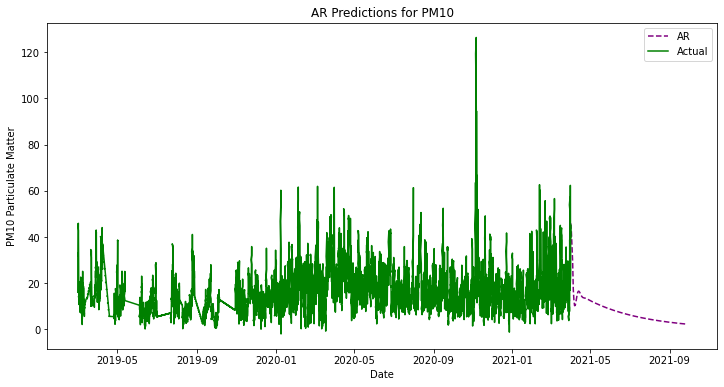

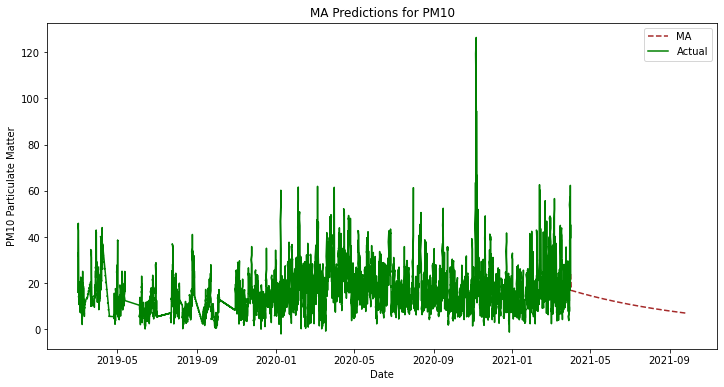

ARIMA Predictions for PM10:
17508    12.334344
17509    10.558254
17510    10.718077
17511    13.987574
17512    17.554889
           ...    
17683    21.020672
17684    21.020672
17685    21.020672
17686    21.020672
17687    21.020672
Name: predicted_mean, Length: 180, dtype: float64

SARIMA Predictions for PM10:
17508    12.334344
17509    10.558254
17510    10.718077
17511    13.987574
17512    17.554889
           ...    
17683    21.020672
17684    21.020672
17685    21.020672
17686    21.020672
17687    21.020672
Name: predicted_mean, Length: 180, dtype: float64

ARMA Predictions for PM10:
17508    11.916139
17509     9.363752
17510     7.735117
17511     7.363782
17512     7.200582
           ...    
17683    16.037562
17684    16.037562
17685    16.037562
17686    16.037562
17687    16.037562
Name: predicted_mean, Length: 180, dtype: float64

AR Predictions for PM10:
17503    45.946459
17504    42.585335
17505    35.511640
17506    29.369946
17507    17.433675
           ...  

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
# Number of forecast steps for 6 months (180 days)
forecast_steps_6_months = 180

# Function to make out-of-sample predictions using the given model
def make_out_of_sample_predictions(model_result, steps):
    return model_result.predict(start=model_result.nobs, end=model_result.nobs + steps - 1)

# Make predictions for 6 months ahead for each model
arima_predictions_pm10 = make_out_of_sample_predictions(arima_results_pm10, forecast_steps_6_months)
sarima_predictions_pm10 = make_out_of_sample_predictions(sarima_results_pm10, forecast_steps_6_months)
arma_predictions_pm10 = make_out_of_sample_predictions(arma_results_pm10, forecast_steps_6_months)
ar_predictions_pm10 = make_out_of_sample_predictions(ar_results_pm10, forecast_steps_6_months)
ma_predictions_pm10 = make_out_of_sample_predictions(ma_results_pm10, forecast_steps_6_months)

# Generate date index for the forecast periods
forecast_periods_pm10 = pd.date_range(start=pm10_series.index[-1], periods=forecast_steps_6_months + 1, closed='right')

# Plot the actual data
plt.figure(figsize=(12, 6))
plt.plot(pm10_series, label='Actual', color='blue')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.title('Actual Data for PM10')
plt.legend()
plt.show()

# Plot the ARIMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods_pm10, arima_predictions_pm10, label='ARIMA', linestyle='--', color='orange')
plt.plot(pm10_series, label='Actual', color='green')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.title('ARIMA Predictions for PM10')
plt.legend()
plt.show()

# Plot the SARIMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods_pm10, sarima_predictions_pm10, label='SARIMA', linestyle='--', color='black')
plt.plot(pm10_series, label='Actual', color='green')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.title('SARIMA Predictions for PM10')
plt.legend()
plt.show()

# Plot the ARMA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods_pm10, arma_predictions_pm10, label='ARMA', linestyle='--', color='red')
plt.plot(pm10_series, label='Actual', color='green')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.title('ARMA Predictions for PM10')
plt.legend()
plt.show()

# Plot the AR predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods_pm10, ar_predictions_pm10, label='AR', linestyle='--', color='purple')
plt.plot(pm10_series, label='Actual', color='green')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.title('AR Predictions for PM10')
plt.legend()
plt.show()

# Plot the MA predictions
plt.figure(figsize=(12, 6))
plt.plot(forecast_periods_pm10, ma_predictions_pm10, label='MA', linestyle='--', color='brown')
plt.plot(pm10_series, label='Actual', color='green')
plt.xlabel('Date')
plt.ylabel('PM10 Particulate Matter')
plt.title('MA Predictions for PM10')
plt.legend()
plt.show()

# Print the predictions for each model
print("ARIMA Predictions for PM10:")
print(arima_predictions_pm10)

print("\nSARIMA Predictions for PM10:")
print(sarima_predictions_pm10)

print("\nARMA Predictions for PM10:")
print(arma_predictions_pm10)

print("\nAR Predictions for PM10:")
print(ar_predictions_pm10)

print("\nMA Predictions for PM10:")
print(ma_predictions_pm10)
